# Geoloc



## infos
Participants : Hélène DALON-DENEE, Dame DIENG, Célien GRIL, Nathan LEBRE

ligne 42368 : photo id 5464485473, correction -> les dates étaient décalée, le # de minutes (25) était collé au titre de la photo ("une lundi matin comme tout les autre ;-(") et le décalage était propagé.

In [2]:
import numpy as np
import pandas as pd
import folium as fl
import hdbscan
import re
import matplotlib.pyplot as plt

In [3]:
read_data = pd.read_csv("../flickr_data2.csv")
len(read_data)

C:\Users\Pyta\AppData\Local\Temp\ipykernel_38348\1384916255.py:1: DtypeWarning: Columns (11,12) have mixed types. Specify dtype option on import or set low_memory=False.
  read_data = pd.read_csv("../flickr_data2.csv")


420240

Retirer les 142 lignes qui ont des valeurs non-nulles qui dépassent les colonnes attendues. (unnamed 16, y'a aussi 2 lignes avec des valeurs dans unnamed 18 mais elles sont comptabilisées dans les autres)

In [4]:
wrong_data = read_data.dropna(how="all", subset=read_data.columns[[16, 18]])
fix_data = read_data.drop(index=wrong_data.index, axis=1)

toDropColumns = read_data.columns[[16, 17, 18]]
fix_data = fix_data.drop(toDropColumns, axis=1)

len(fix_data)

420098

Retirer les tuples dupliquée (ignore id et tags pour enlever certains dupliqué quand un post est modifié et certains carousels, passe de 187544 à 175688 donc pas tant que ça, la majorité sont dupliqués point barre)

In [5]:
fix_data.drop_duplicates(inplace=True, subset=fix_data.columns.drop(["id", " tags"]), keep='last')
len(fix_data)

175689

Retirer les carousels

In [6]:
fix_data.drop_duplicates(inplace=True, subset=fix_data.columns.drop(["id", " title"]))
len(fix_data)

161123

Retirer les tags null pour le text pattern mining

In [7]:
text_data = fix_data.dropna(how='all', subset=[" tags"])
len(text_data)

120617

## Clustering

### HBDSCAN

In [7]:
data2D = fix_data[[' lat', ' long']]
coords_rad = np.radians(data2D)
coords_rad.head()

,lat,long
9420,0.798799,0.084408
9421,0.798799,0.084408
9422,0.798674,0.084585
9423,0.798677,0.084250
9424,0.798696,0.084237


In [ ]:
clusterer = hdbscan.HDBSCAN(min_cluster_size = 100, min_samples = 50, metric= 'haversine')
labels = clusterer.fit_predict(coords_rad)
df = data2D.copy()
df["cluster"] = labels
pois = (
    df[df.cluster != -1]
    .groupby("cluster")
    .agg(
        lat_mean=(" lat", "mean"),
        lon_mean=(" long", "mean"),
        nb_photos=("cluster", "count")
    )
    .sort_values("nb_photos", ascending=False)
)

## Partie sur la carte.

In [1]:
# Réinitialiser les indices pour éviter les problèmes
donnees_geoloc_reset = data2D.reset_index(drop=True)
labels_reset = labels.copy()

# Créer la carte centrée sur Lyon
map_hdbscan = fl.Map(
    location=[45.757778, 4.832222],
    zoom_start=12
)

# Couleurs pour les clusters
colors = ['red', 'blue', 'green', 'purple', 'orange', 'darkred', 'lightred', 
          'darkblue', 'darkgreen', 'cadetblue', 'darkpurple', 'white', 'pink', 'gray']

# Ajouter les points avec les couleurs des clusters
for idx in range(len(donnees_geoloc_reset)):
    cluster_id = labels_reset[idx]
    row = donnees_geoloc_reset.iloc[idx]
    
    # Sauter le bruit (cluster -1)
    if cluster_id == -1:
        continue
    
    # Choisir la couleur selon le cluster
    color = colors[int(cluster_id) % len(colors)]
    
    # Ajouter un marqueur
    fl.CircleMarker(
        location=[row[' lat'], row[' long']],
        radius=3,
        popup=f'Cluster {cluster_id}',
        color=color,
        fill=True,
        fillColor=color,
        fillOpacity=0.7,
        weight=1
    ).add_to(map_hdbscan)

# Ajouter les points de bruit en gris transparent
for idx in range(len(donnees_geoloc_reset)):
    if labels_reset[idx] == -1:
        row = donnees_geoloc_reset.iloc[idx]
        fl.CircleMarker(
            location=[row[' lat'], row[' long']],
            radius=1,
            popup='Bruit',
            color='gray',
            fill=True,
            fillColor='gray',
            fillOpacity=0.2,
            weight=0.5
        ).add_to(map_hdbscan)

# Ajouter les centres des clusters (POIs)
for cluster_id, poi_row in pois.iterrows():
    fl.Marker(
        location=[poi_row['lat_mean'], poi_row['lon_mean']],
        popup=f"Cluster {cluster_id}<br>{int(poi_row['nb_photos'])} photos",
        icon=fl.Icon(color=colors[int(cluster_id) % len(colors)], icon='info-sign')
    ).add_to(map_hdbscan)

# Sauvegarder la carte
map_hdbscan.save('map_hdbscan.html')
print("Carte HDBSCAN sauvegardée dans 'map_hdbscan.html'")
print(f"\nRésumé des clusters HDBSCAN:")
print(pois)

NameError: name 'data2D' is not defined

# Text mining

In [ ]:
nona_df = text_data[' tags'].dropna()

#count = nona_df.apply(lambda x: len(re.findall(r'[^\W\d_]++', str(x)))).sum()
#print(f"Number of tags in the cleaned dataset: {count}")
print(nona_df)

9420                                        lyon,operahouse
9421                                        lyon,operahouse
9422                                  365,rubberduck,iphone
9423                                         lyon,vieuxlyon
9424                                         lyon,vieuxlyon
                                ...                        
420234    europe,france,lyon,croixrousse,streetart,wall,...
420235    europe,france,lyon,croixrousse,streetart,wheat...
420237    auvergnerhônealpes,rhône,lyonnais,valléedurhôn...
420238    auvergnerhônealpes,rhône,lyonnais,valléedurhôn...
420239    ngc,lyon,paysage,landscape,ville,urbain,town,tour
Name:  tags, Length: 120617, dtype: object


In [ ]:
idf={}  # Inverse Document Frequency dictionary
total_docs = len(nona_df)
filtered_tags=["cospla","japa","feminicide","girl","hair","overwatch","tracer","aplusphoto","view","fiume","night","chaise","chair","iphone","streetphotography","rue","gens","nuit","francia","poste","river","notte","night"]

for tags in nona_df:
    unique_tags = set(re.findall(r'[^\W\d_]{2,}', str(tags)))    
    unique_tags = {tag.lower() for tag in unique_tags if not any(bad in tag for bad in filtered_tags)}  # Normalize to lowercase
    for tag in unique_tags:
        idf[tag] = idf.get(tag, 0) + 1

for tag in idf:
    idf[tag] = total_docs / idf[tag]

print("IDF values for tags:")
for tag, value in idf.items():
    print(f"{tag}: {value}")

IDF values for tags:
operahouse: 2566.31914893617
lyon: 1.5737920956146187
rubberduck: 60308.5
vieuxlyon: 49.514367816091955
parcdeshauteurs: 7095.117647058823
vert: 299.29776674937966
heart: 1507.7125
green: 249.7246376811594
coeur: 1698.8309859154929
flore: 4020.5666666666666
cortex: 4159.206896551724
macro: 210.50087260034903
closeup: 2412.34
flower: 225.45233644859812
fleur: 223.7792207792208
red: 217.72021660649818
rouge: 204.78268251273346
bouchon: 1608.2266666666667
restaurant: 365.5060606060606
georges: 1453.2168674698796
resto: 1945.4354838709678
saint: 272.8891402714932
brasserie: 2319.5576923076924
bistrot: 2741.2954545454545
choucroute: 120617.0
parctêtedor: 2116.0877192982457
geotagged: 103.71195184866724
christianbaudet: 1127.2616822429907
fourvière: 45.74023511566174
panorama: 115.53352490421456
candle: 3890.8709677419356
day: 353.7155425219941
bokeh: 391.6136363636364
baramericain: 60308.5
kitty: 5743.666666666667
january: 6030.85
turquoise: 8615.5
kitten: 1748.07246376

In [ ]:
#Cleaning by the lower IDF values

threshold = 18  # Default threshold
filtered_tags = []

idf = {tag: value for tag, value in idf.items() if value >= threshold}
count= len(idf)
print(f"Number of tags after filtering with threshold {threshold}: {count}")
print("IDF values for tags:")
for tag, value in idf.items():
    print(f"{tag}: {value}")

tag_df=pd.DataFrame(list(idf.items()), columns=['tag', 'idf_value'])

Number of tags after filtering with threshold 18: 39795
IDF values for tags:
operahouse: 2566.31914893617
rubberduck: 60308.5
vieuxlyon: 49.514367816091955
parcdeshauteurs: 7095.117647058823
vert: 299.29776674937966
heart: 1507.7125
green: 249.7246376811594
coeur: 1698.8309859154929
flore: 4020.5666666666666
cortex: 4159.206896551724
macro: 210.50087260034903
closeup: 2412.34
flower: 225.45233644859812
fleur: 223.7792207792208
red: 217.72021660649818
rouge: 204.78268251273346
bouchon: 1608.2266666666667
restaurant: 365.5060606060606
georges: 1453.2168674698796
resto: 1945.4354838709678
saint: 272.8891402714932
brasserie: 2319.5576923076924
bistrot: 2741.2954545454545
choucroute: 120617.0
parctêtedor: 2116.0877192982457
geotagged: 103.71195184866724
christianbaudet: 1127.2616822429907
fourvière: 45.74023511566174
panorama: 115.53352490421456
candle: 3890.8709677419356
day: 353.7155425219941
bokeh: 391.6136363636364
baramericain: 60308.5
kitty: 5743.666666666667
january: 6030.85
turquois

In [ ]:
mining_data = df.copy()
tags_data = tag_df["tag"].str.split()
mining_data = mining_data.merge(tags_data, left_index=True, right_index=True)
mining_data = mining_data.dropna(subset=["tag"])


In [ ]:
print(mining_data)

             lat      long  cluster                  tag
9420   45.767811  4.836215      257          [bocusedor]
9421   45.767811  4.836215      257      [envoyéspecial]
9422   45.760649  4.846391      122            [labbaye]
9423   45.760846  4.827150      297  [cuisinierdusiècle]
9424   45.761924  4.826399       -1    [papedelacuisine]
...          ...       ...      ...                  ...
39787  45.837448  4.826248       32             [spadix]
39788  45.837448  4.826248       32          [anthurium]
39789  45.837448  4.826248       32       [grandsserres]
39792  45.837448  4.826248       32              [dekor]
39793  45.837448  4.826248       32              [wagen]

[10689 rows x 4 columns]


In [ ]:
#erreur pour le moment
tags_dict = {}
for row in mining_data.itertuples():
    clust = getattr(row, 'cluster')
    tags = getattr(row, 'tag')
    if tags_dict.keys().__contains__(clust):
        tags_clust = tags_dict[clust]
        for tag in tags:
            #print(tag)
            if tags_clust.keys().__contains__(tag):
                tags_clust[tag] += 1
            else:
                tags_clust[tag] = 1
        tags_dict[clust] = tags_clust
    else:
        tags_clust = {}
        for tag in tags:
            if tags_clust.keys().__contains__(tag):
                tags_clust[tag] += 1
            else:
                tags_clust[tag] = 1
        tags_dict[clust] = tags_clust


In [ ]:
tags_dict

{257: {'bocusedor': 1,
  'envoyéspecial': 1,
  'debrousse': 1,
  'loyon': 1,
  'eglisesaintpaul': 1,
  'odeaubois': 1,
  'bicicleta': 1,
  'lcocktailsvespermartinivodka': 1,
  'thibaultroland': 1,
  'summaron': 1,
  'ferdinand': 1,
  'abodeτουxάουσ': 1,
  'খল': 1,
  'toiletpaper': 1,
  'ddcee': 1,
  'lamouche': 1,
  'menestrier': 1,
  'bau': 1,
  'baubo': 1,
  'passerelledupalaisdejusticelyon': 1,
  'michaelelmgreen': 1,
  'grandtrou': 1,
  'democritus': 1,
  'hôtelroyal': 1,
  'brunante': 1,
  'beg': 1,
  'businova': 1,
  'quaiperrache': 1,
  'clio': 1,
  'electionspolitiquepoliticienumppartie': 1,
  'neuillysurseine': 1,
  'ministerofeconomy': 1,
  'hommepolitiquefrançais': 1,
  'lesrougonmacquart': 1,
  'purses': 1,
  'lysistrata': 1,
  'mauves': 1,
  'backside': 1,
  'neonsign': 1,
  'vx': 1,
  'coursieravelo': 1,
  'payant': 1,
  'bloginlyon': 1,
  'audessus': 1,
  'teppaz': 1,
  'sprocket': 1,
  'muros': 1,
  'bagnole': 1,
  '大斑啄木鸟': 1,
  'lalimonadedemarinette': 1,
  'visages': 

In [ ]:
# Réinitialiser les indices pour éviter les problèmes
donnees_geoloc_reset = data2D.reset_index(drop=True)
labels_reset = labels.copy()

# Créer la carte centrée sur Lyon
map_hdbscan = fl.Map(
    location=[45.757778, 4.832222],
    zoom_start=12
)

# Couleurs pour les clusters
colors = ['red', 'blue', 'green', 'purple', 'orange', 'darkred', 'lightred', 
          'darkblue', 'darkgreen', 'cadetblue', 'darkpurple', 'white', 'pink', 'gray']

# Ajouter les points avec les couleurs des clusters
for idx in range(len(donnees_geoloc_reset)):
    cluster_id = labels_reset[idx]
    row = donnees_geoloc_reset.iloc[idx]
    
    # Sauter le bruit (cluster -1)
    if cluster_id == -1:
        continue
    
    # Choisir la couleur selon le cluster
    color = colors[int(cluster_id) % len(colors)]
    
    # Ajouter un marqueur
    fl.CircleMarker(
        location=[row[' lat'], row[' long']],
        radius=3,
        popup=f'Cluster {cluster_id}',
        color=color,
        fill=True,
        fillColor=color,
        fillOpacity=0.7,
        weight=1
    ).add_to(map_hdbscan)

# Ajouter les points de bruit en gris transparent
for idx in range(len(donnees_geoloc_reset)):
    if labels_reset[idx] == -1:
        row = donnees_geoloc_reset.iloc[idx]
        fl.CircleMarker(
            location=[row[' lat'], row[' long']],
            radius=1,
            popup='Bruit',
            color='gray',
            fill=True,
            fillColor='gray',
            fillOpacity=0.2,
            weight=0.5
        ).add_to(map_hdbscan)

# Ajouter les centres des clusters (POIs)
for cluster_id, poi_row in pois.iterrows():
    fl.Marker(
        location=[poi_row['lat_mean'], poi_row['lon_mean']],
        popup=f"Cluster {cluster_id}<br>{int(poi_row['nb_photos'])} photos <br>Tags: {', '.join(tags_dict.get(cluster_id, {}).keys())}",
        icon=fl.Icon(color=colors[int(cluster_id) % len(colors)], icon='info-sign')
    ).add_to(map_hdbscan)

# Sauvegarder la carte
map_hdbscan.save('map_tag_on.html')
print("Carte HDBSCAN sauvegardée dans 'map_tag_on.html'")
print(f"\nRésumé des clusters HDBSCAN:")
print(pois)

Carte HDBSCAN sauvegardée dans 'map_tag_on.html'

Résumé des clusters HDBSCAN:
          lat_mean  lon_mean  nb_photos
cluster                                
32       45.837448  4.826248       3748
90       45.732627  4.818266       2353
95       45.741761  4.817054       2174
33       45.837410  4.826163       2159
297      45.760934  4.826798       2025
...            ...       ...        ...
100      45.780521  4.872484        103
7        45.690163  4.786463        102
107      45.769953  4.862777        102
274      45.766609  4.826910        101
114      45.771234  4.845757        100

[299 rows x 3 columns]


## Scope of time

Étudions les mois à Lyon

### 1.Préparation des données


In [9]:
data_time = fix_data[[' date_taken_day', ' date_taken_month', ' lat', ' long']]
print(data_time)

        date_taken_day  date_taken_month        lat      long
9420                31                 8  45.767811  4.836215
9421                31                 8  45.767811  4.836215
9422                21                 2  45.760649  4.846391
9423                10                 5  45.760846  4.827150
9424                10                 5  45.761924  4.826399
...                ...               ...        ...       ...
420235              30                 9  45.758316  4.825197
420236               5                10  45.762635  4.837299
420237              27                 9  45.763657  4.836012
420238              27                 9  45.763657  4.836012
420239              28                 9  45.758181  4.831967

[161123 rows x 4 columns]


In [10]:
count_month= data_time[' date_taken_month'].value_counts().sort_index()
df_month = {mois : i for mois, i in data_time.groupby(' date_taken_month')}
print(count_month)
returned_pois= {}

 date_taken_month
1        9238
2        8343
3       11727
4       15314
5       13598
6       13698
7       14818
8       10614
9       12497
10      13190
11      13437
12      24648
2011        1
Name: count, dtype: int64


In [16]:
# Créer la carte de base centrée sur Lyon
map = fl.Map(
        location=[45.757778, 4.832222],
        zoom_start=12,
        tiles='OpenStreetMap'
    )
    
# Dictionnaire pour stocker les feature groups par mois
month_groups = {}
all_labels = {}
all_df={}
clusterer = hdbscan.HDBSCAN(min_cluster_size = 100, min_samples = 50, metric= 'haversine')




for i in df_month.keys():


    data2D = data_time[data_time[' date_taken_month'] == i][[' lat', ' long']].reset_index(drop=True)
    if len(data2D) < 50:  # ou < min_cluster_size
        print(f"Mois {i}: pas assez de données ({len(data2D)} points), ignoré")
        continue
    
    coords_rad = np.radians(data2D)
    labels = clusterer.fit_predict(coords_rad)
    all_labels[i] = labels
    all_df[i] = data2D.copy()

    all_df[i]["cluster"] = labels
    pois = (
        all_df[i][all_df[i].cluster != -1]
        .groupby("cluster")
        .agg(
            lat_mean=(" lat", "mean"),
        lon_mean=(" long", "mean"),
        nb_photos=("cluster", "count")
    )
    .sort_values("nb_photos", ascending=False)
)
    returned_pois[i] = pois
    print(f"Mois {i}: {len(pois)} clusters trouvés")

      
       

    


Mois 1: 15 clusters trouvés
Mois 2: 23 clusters trouvés
Mois 3: 28 clusters trouvés
Mois 4: 31 clusters trouvés
Mois 5: 32 clusters trouvés
Mois 6: 31 clusters trouvés
Mois 7: 31 clusters trouvés
Mois 8: 20 clusters trouvés
Mois 9: 21 clusters trouvés
Mois 10: 34 clusters trouvés
Mois 11: 33 clusters trouvés
Mois 12: 54 clusters trouvés
Mois 2011: pas assez de données (1 points), ignoré


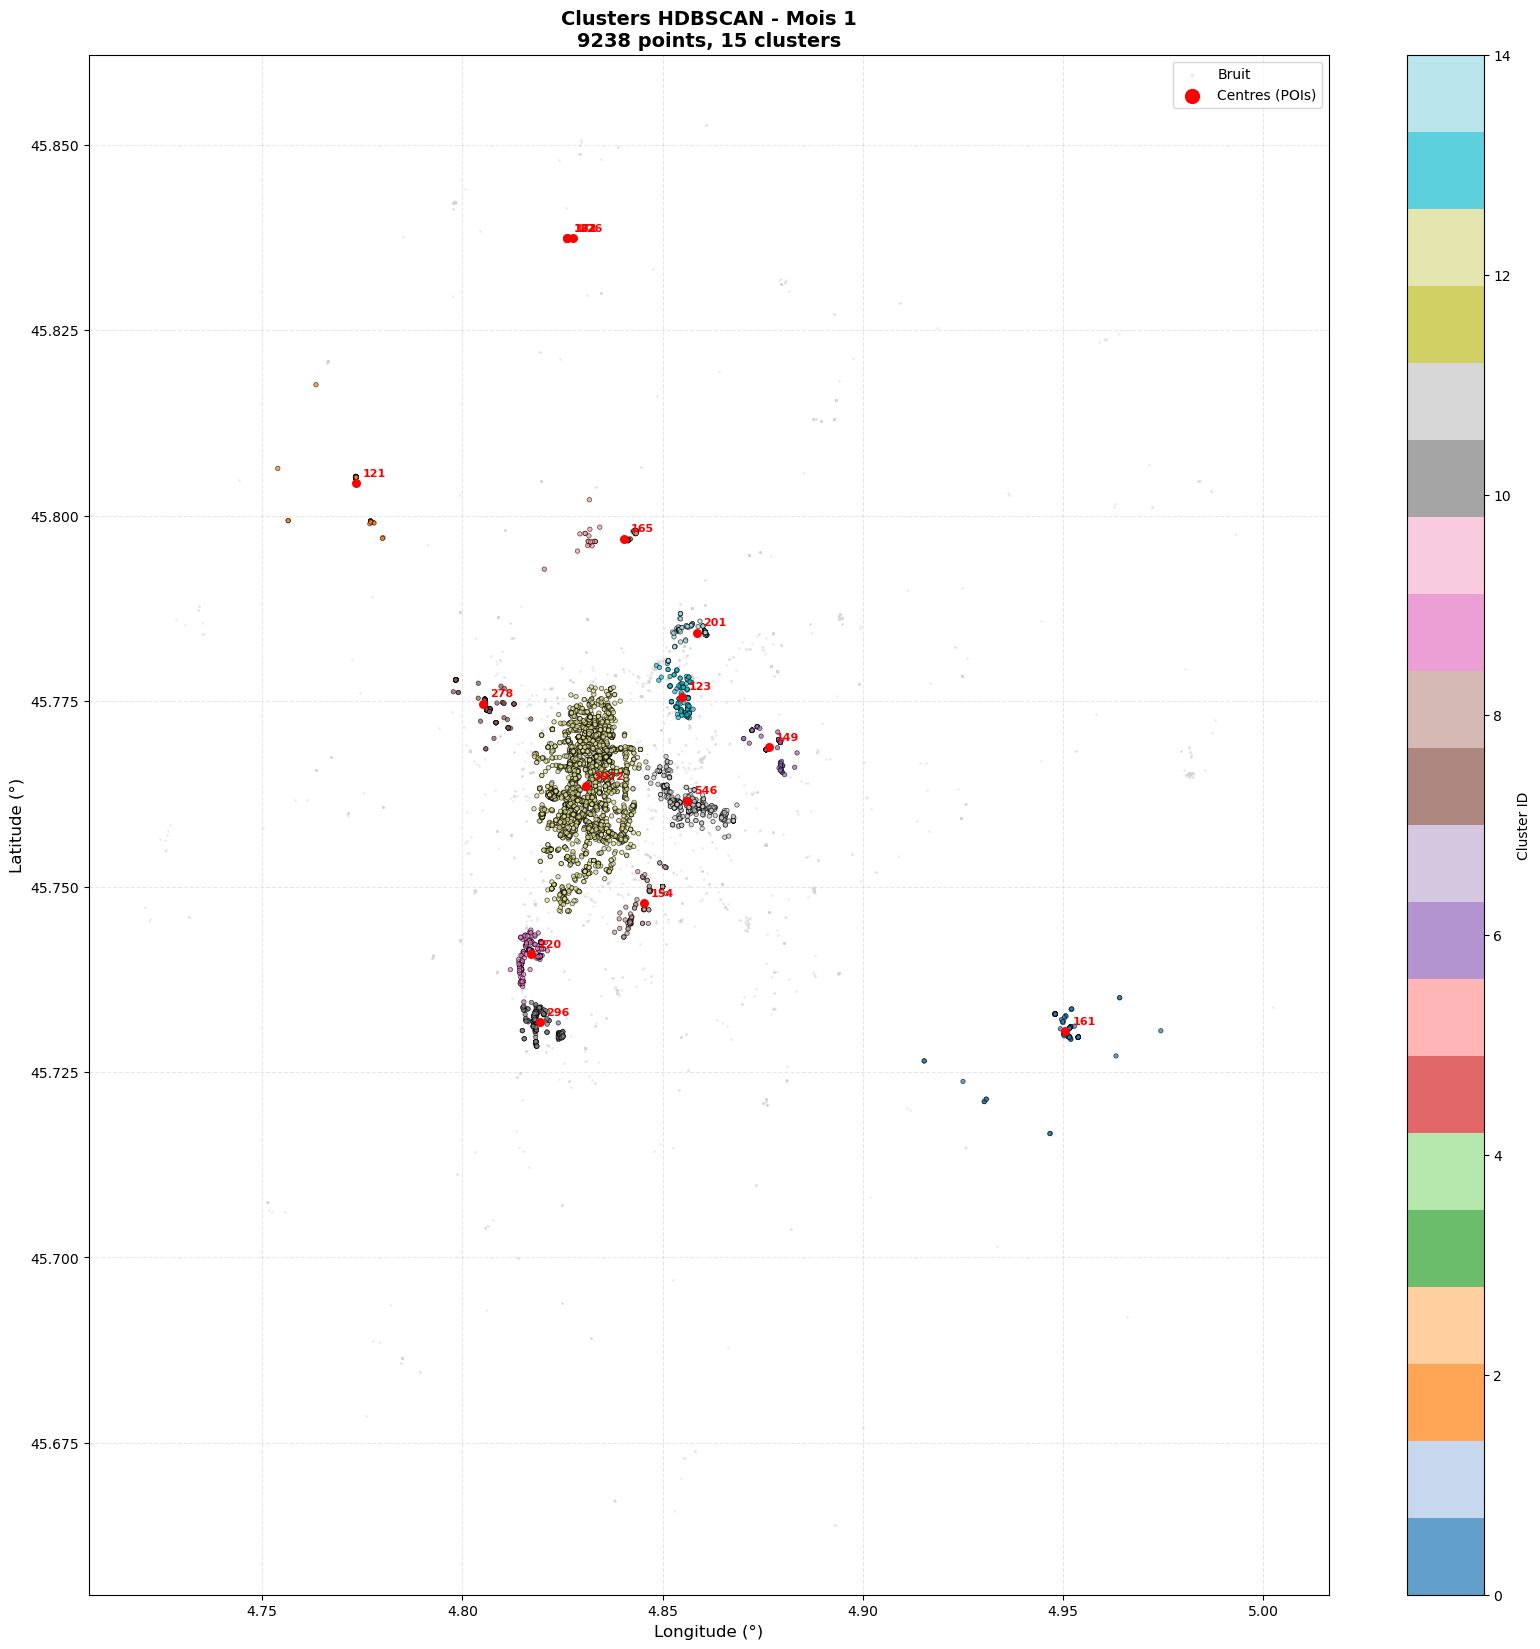

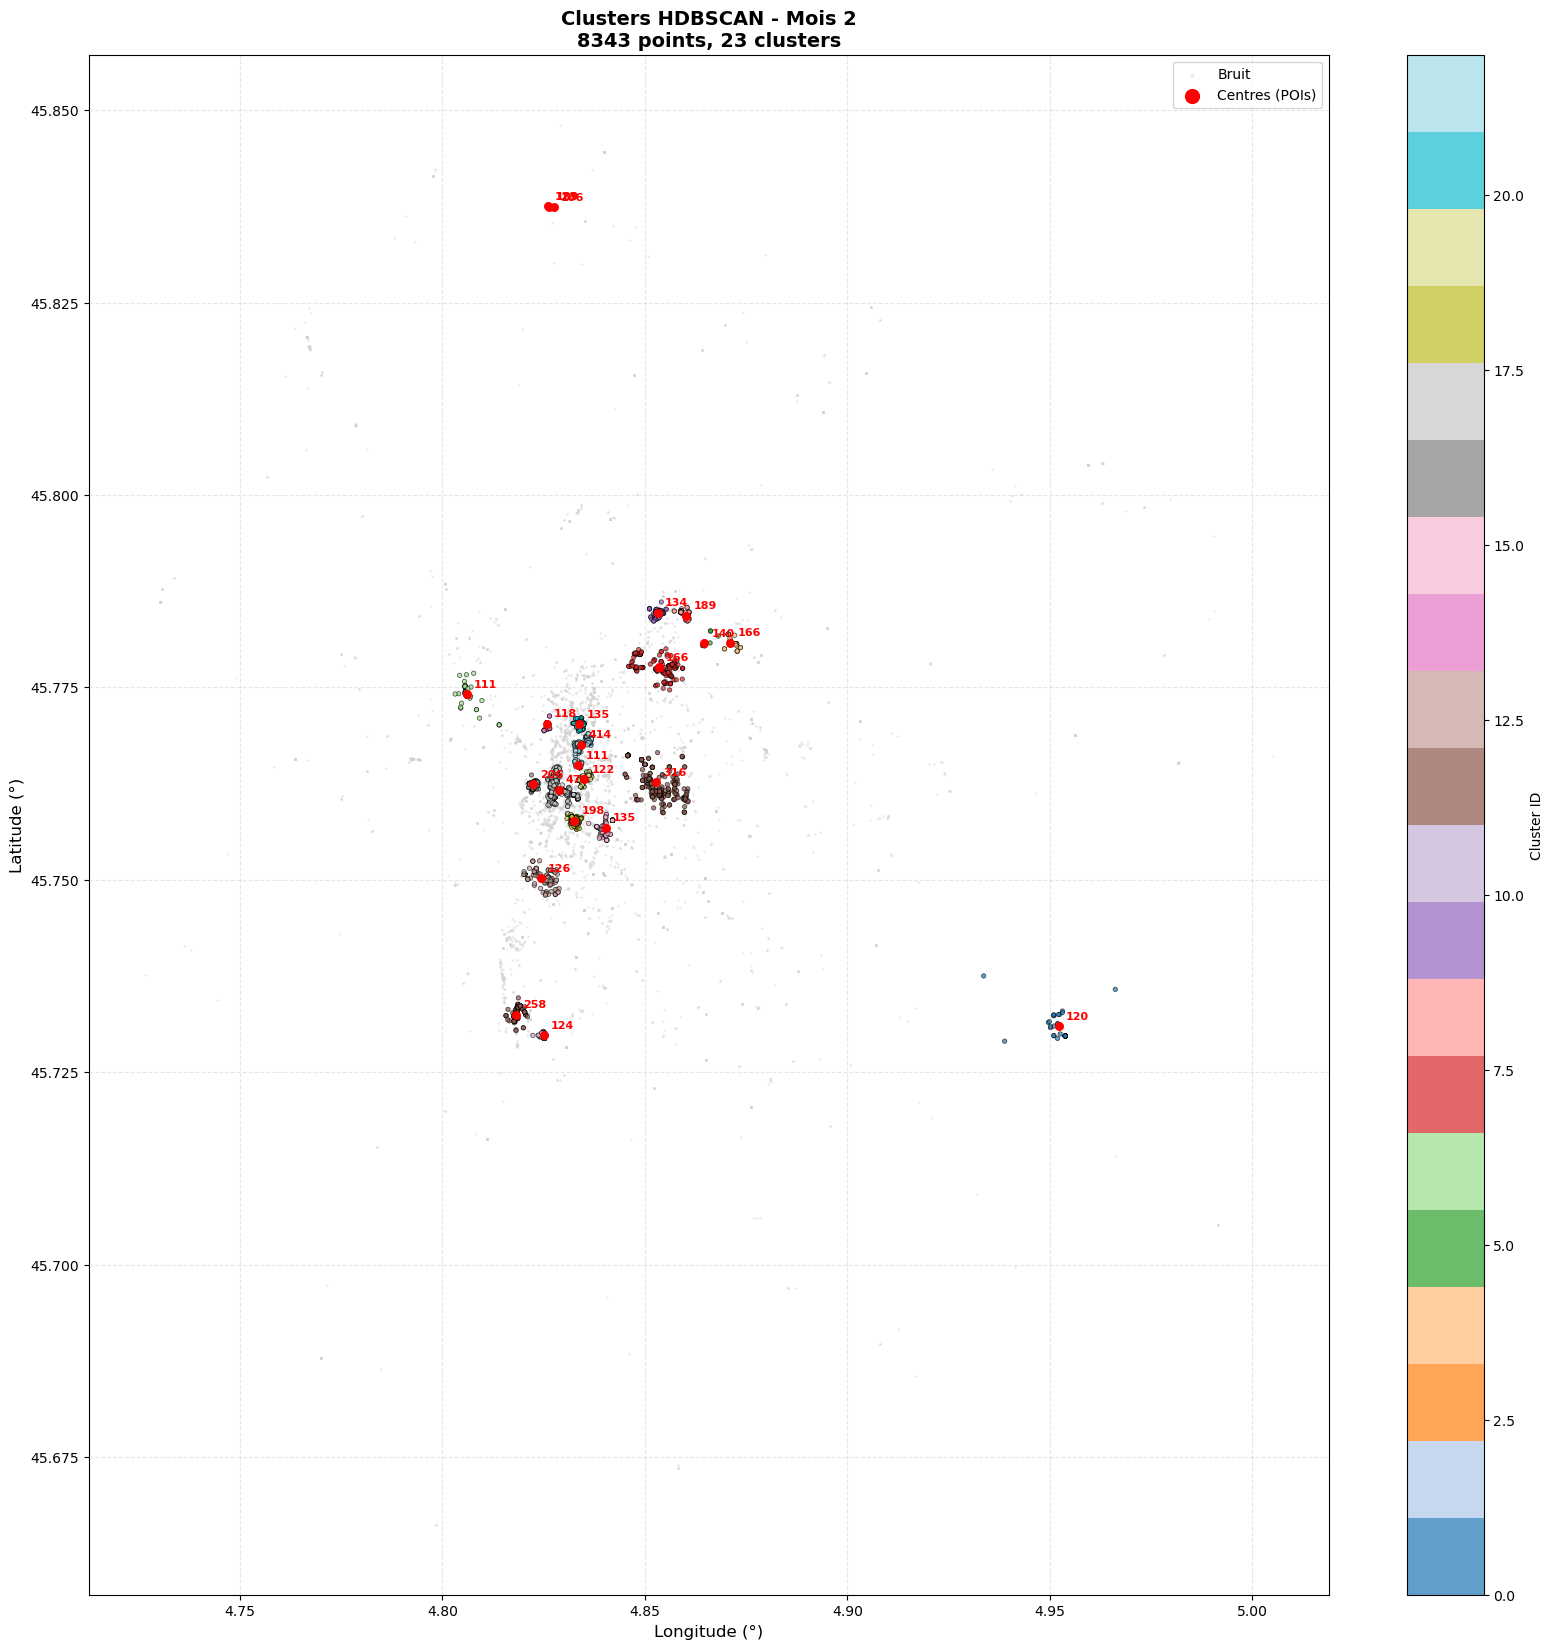

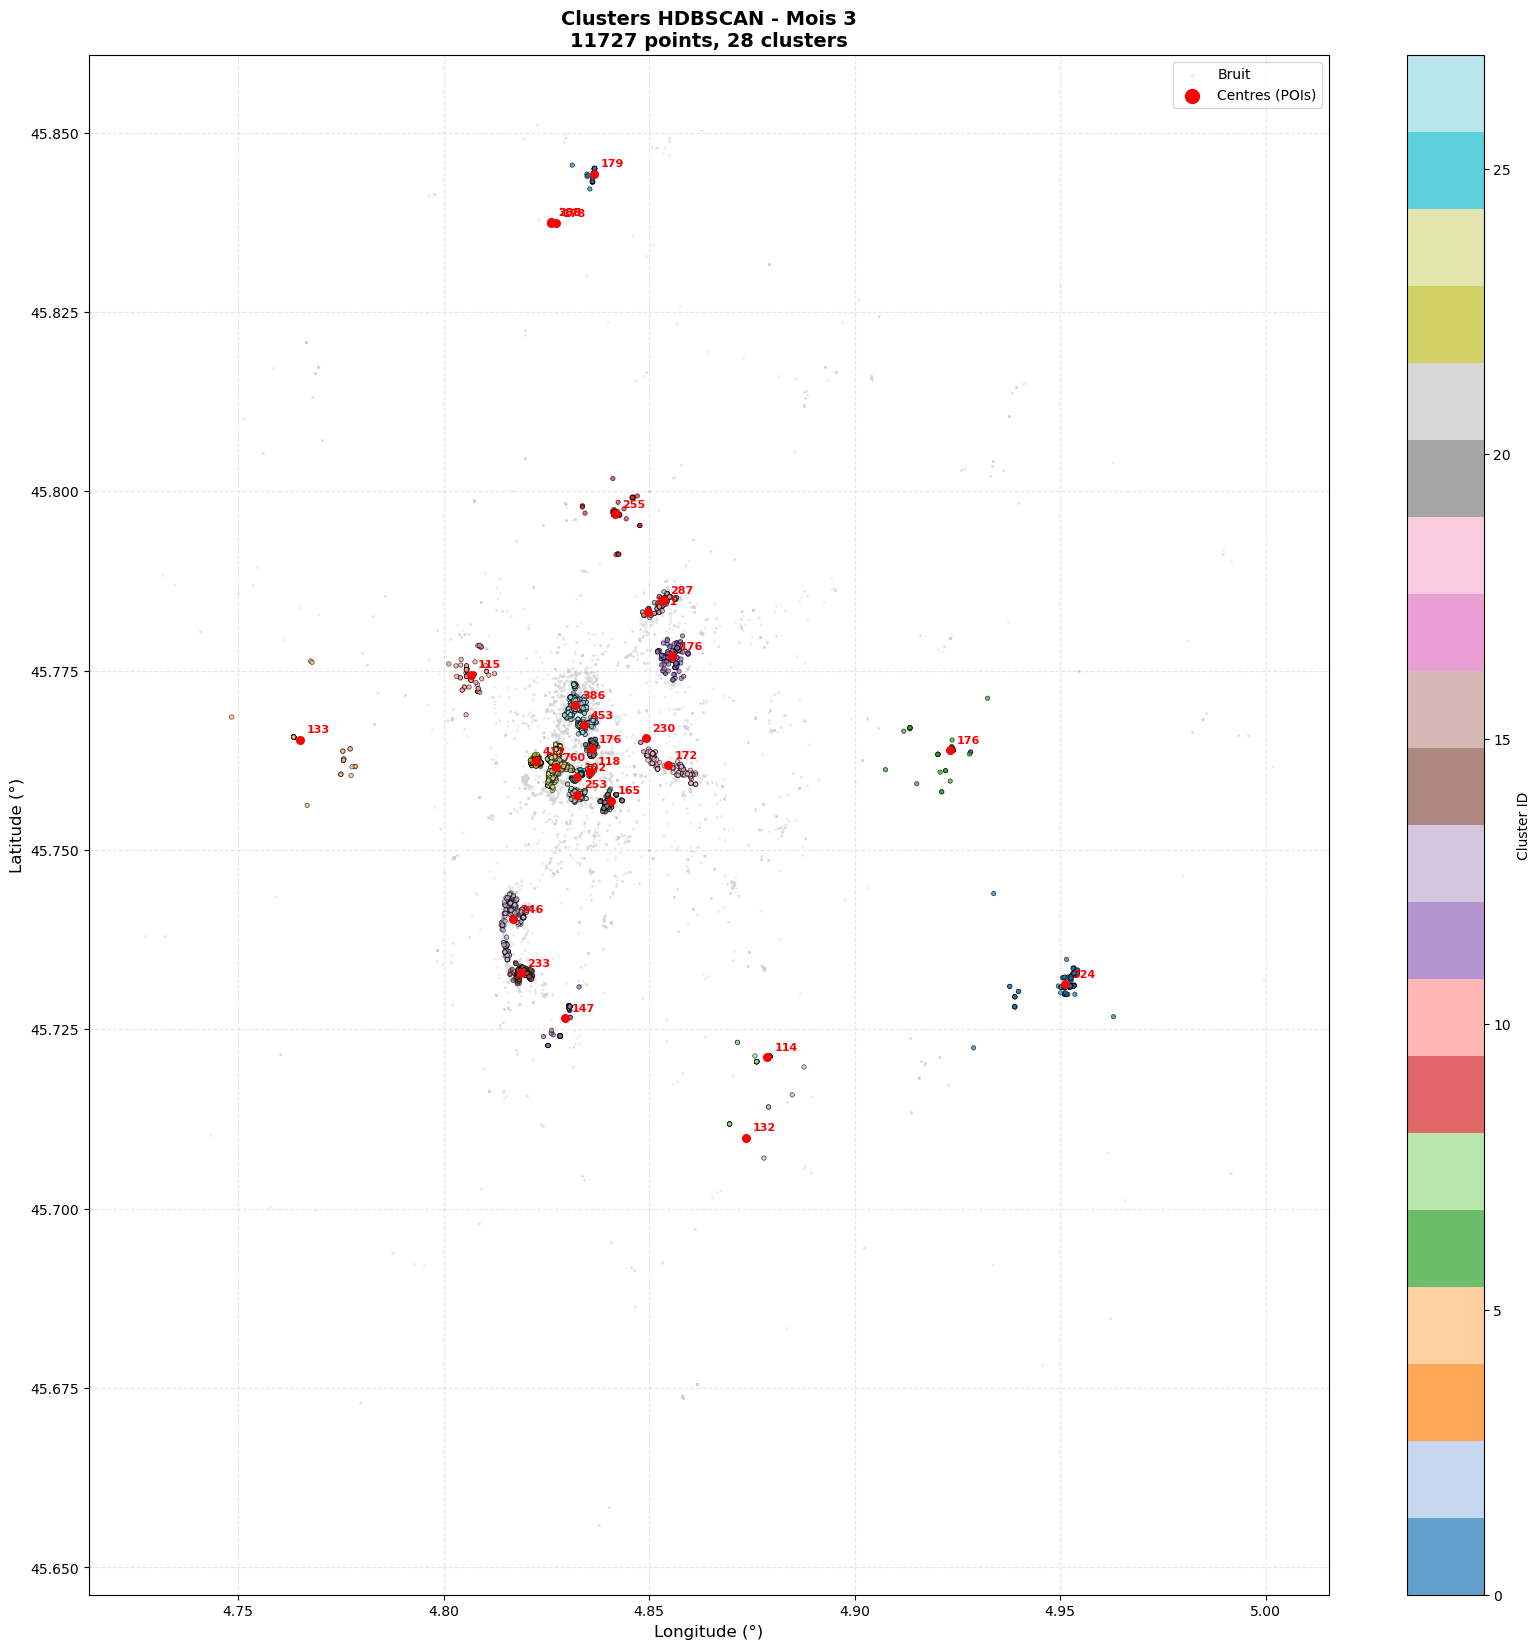

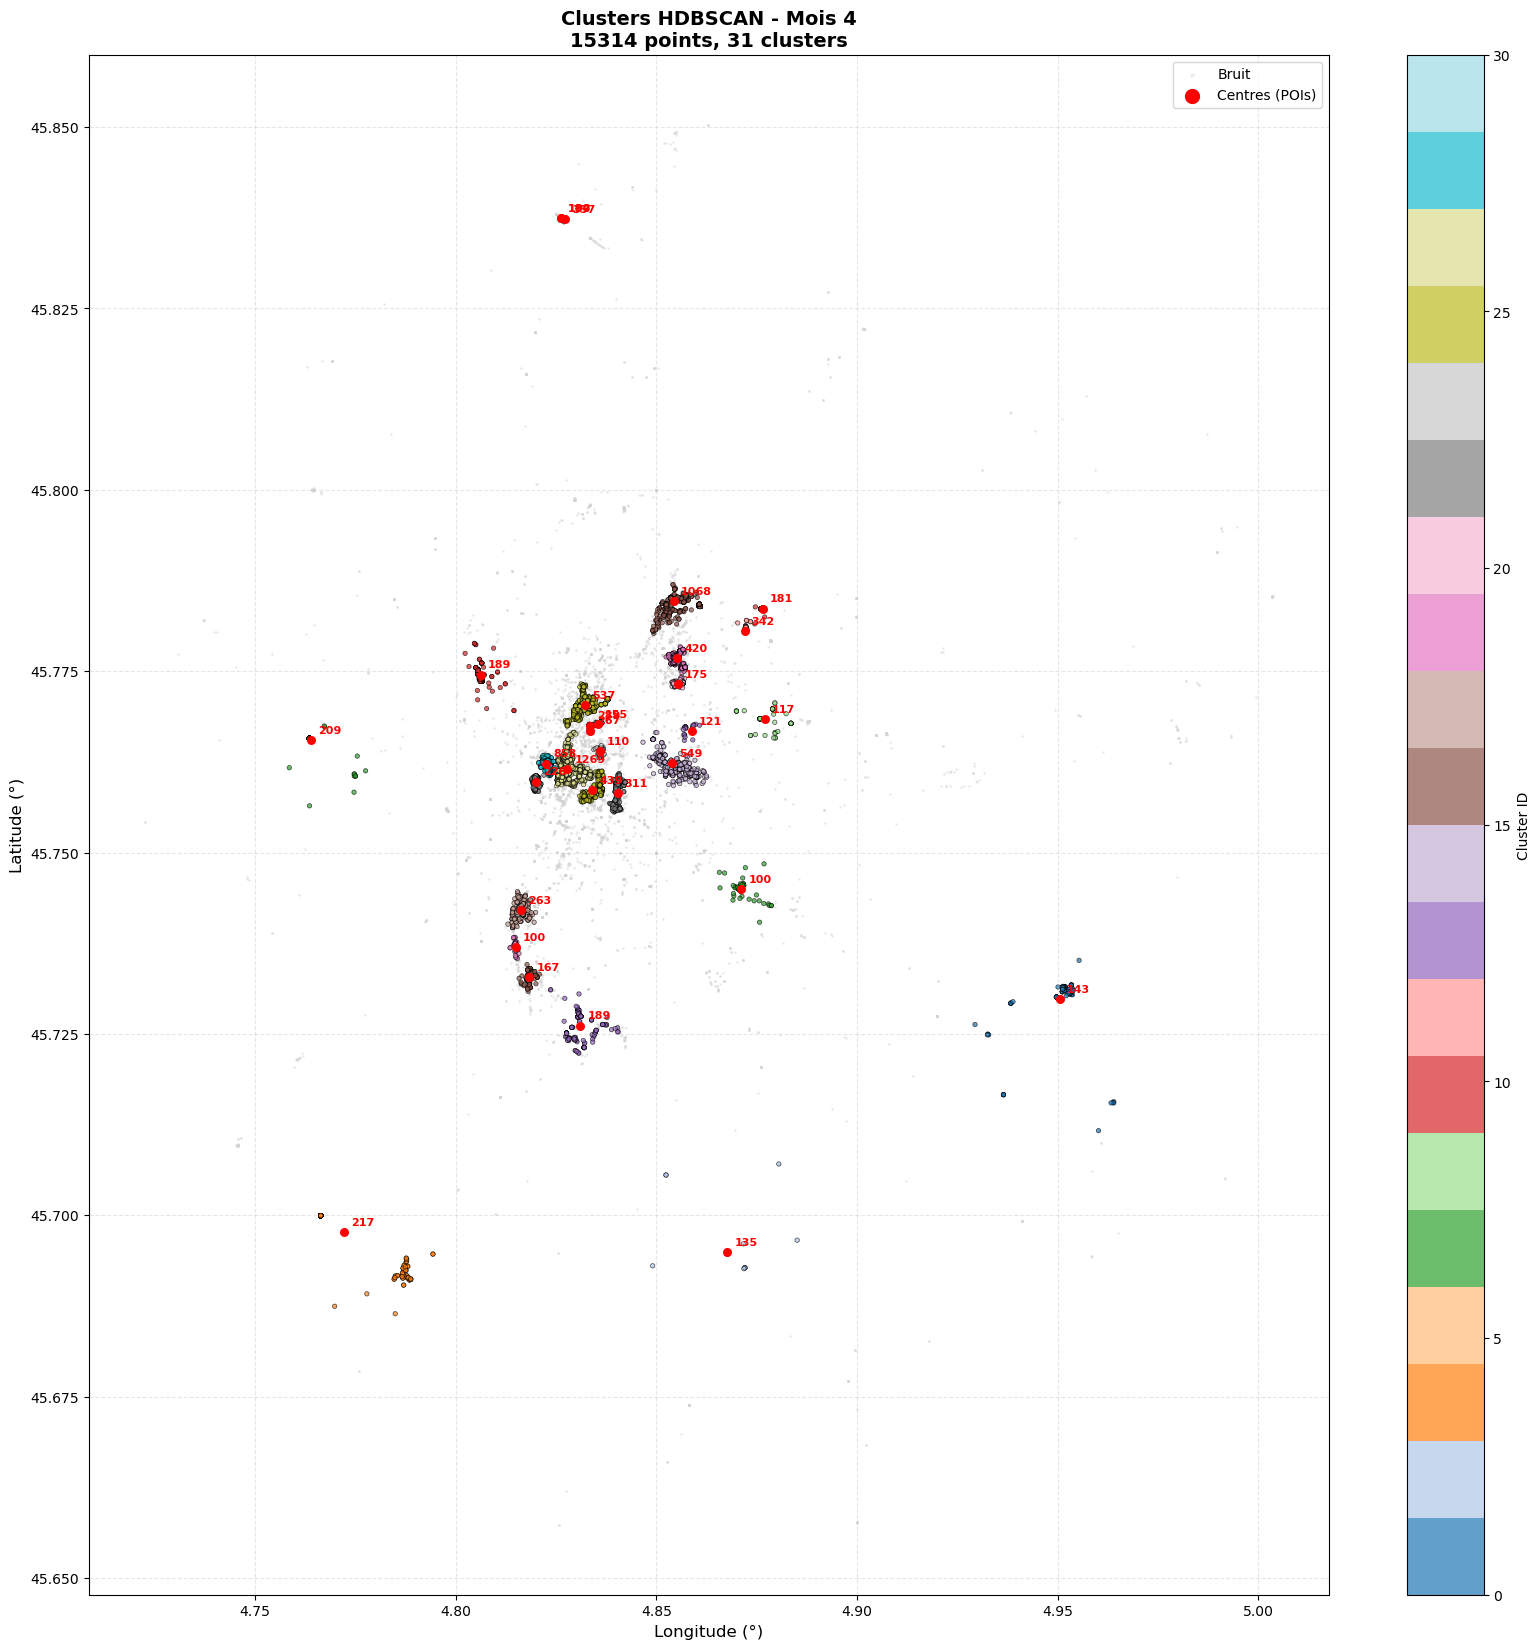

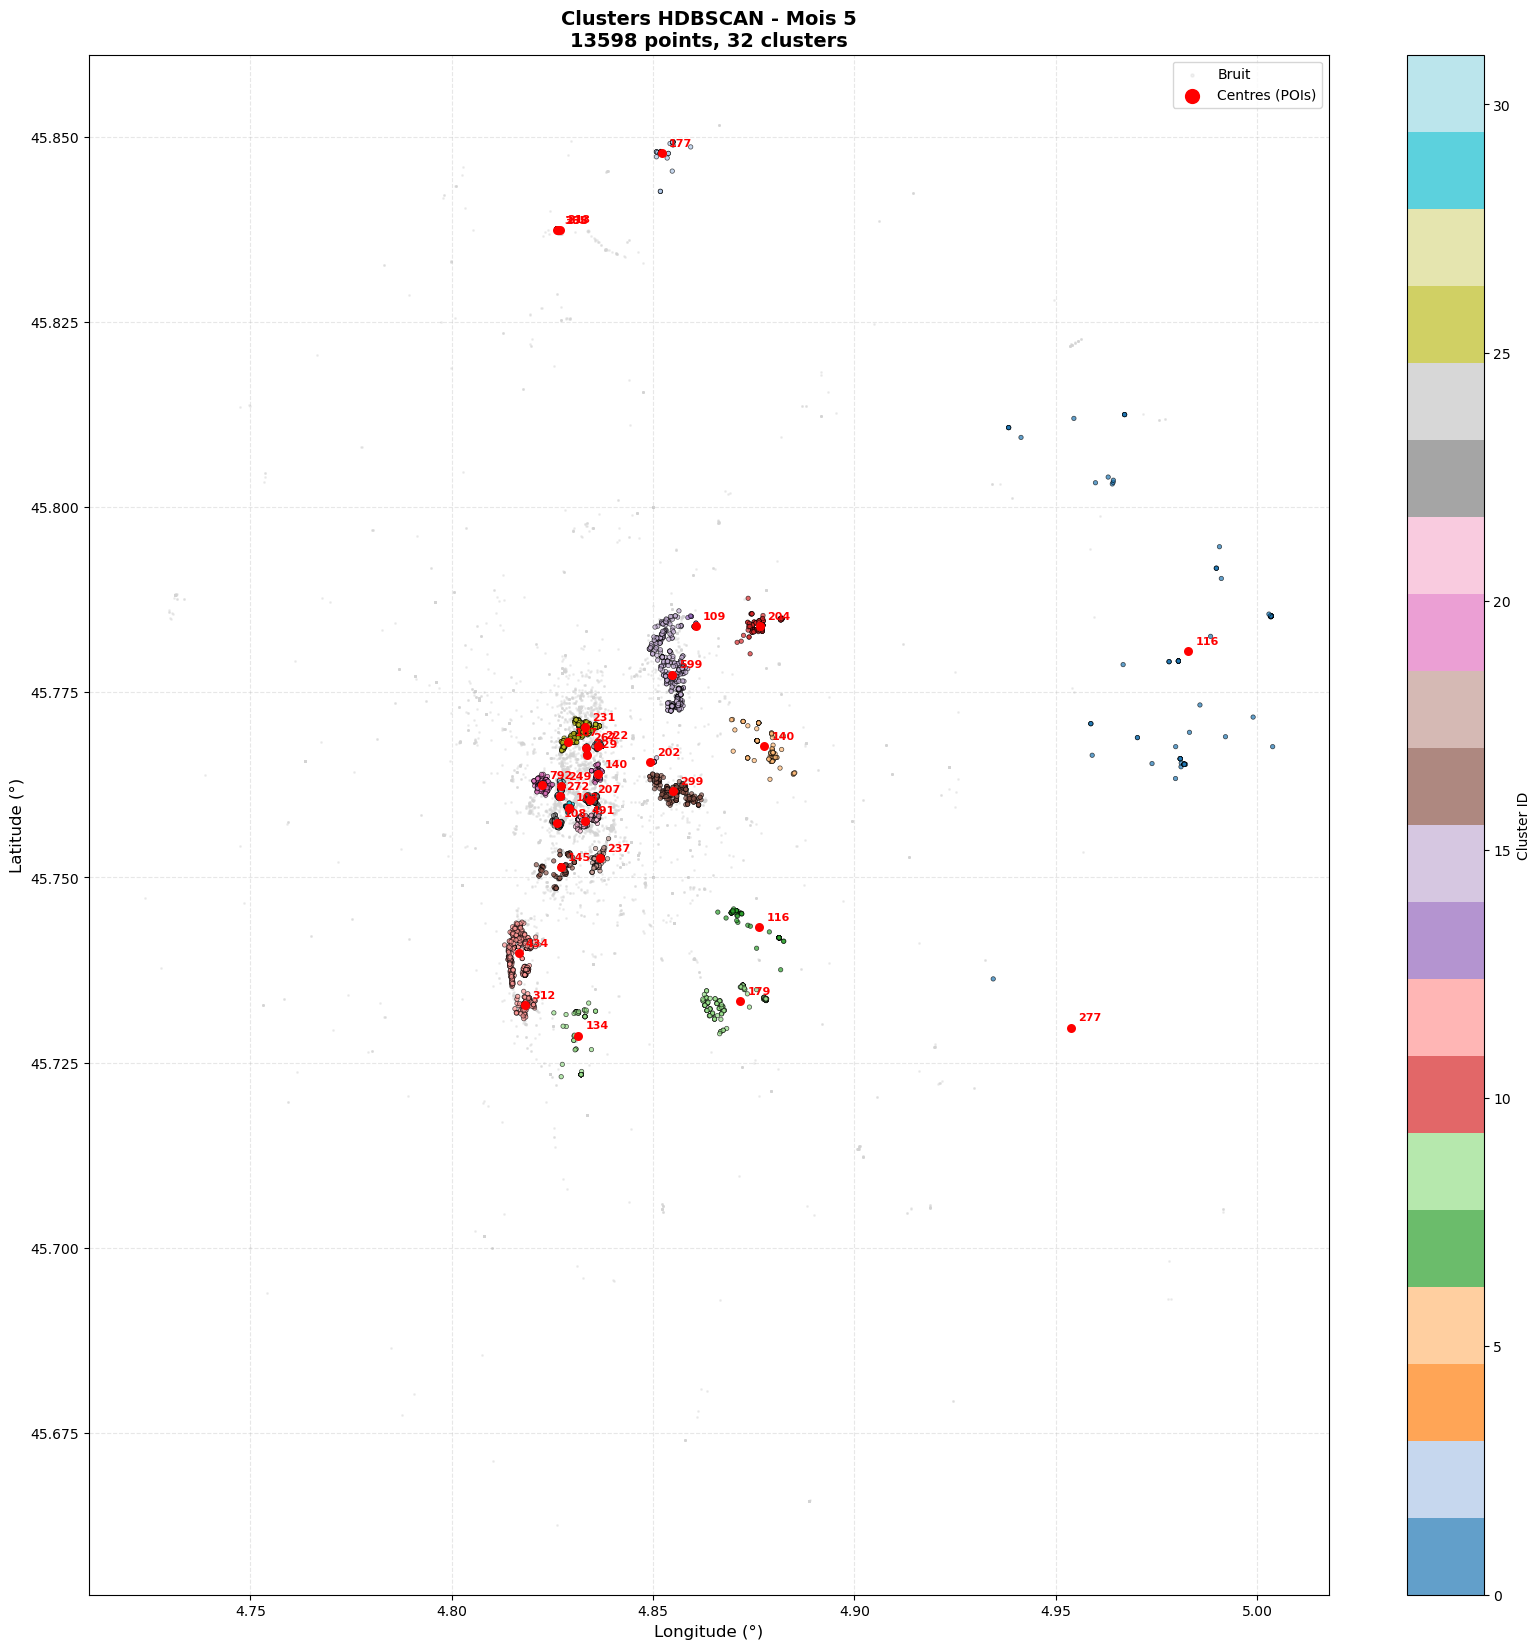

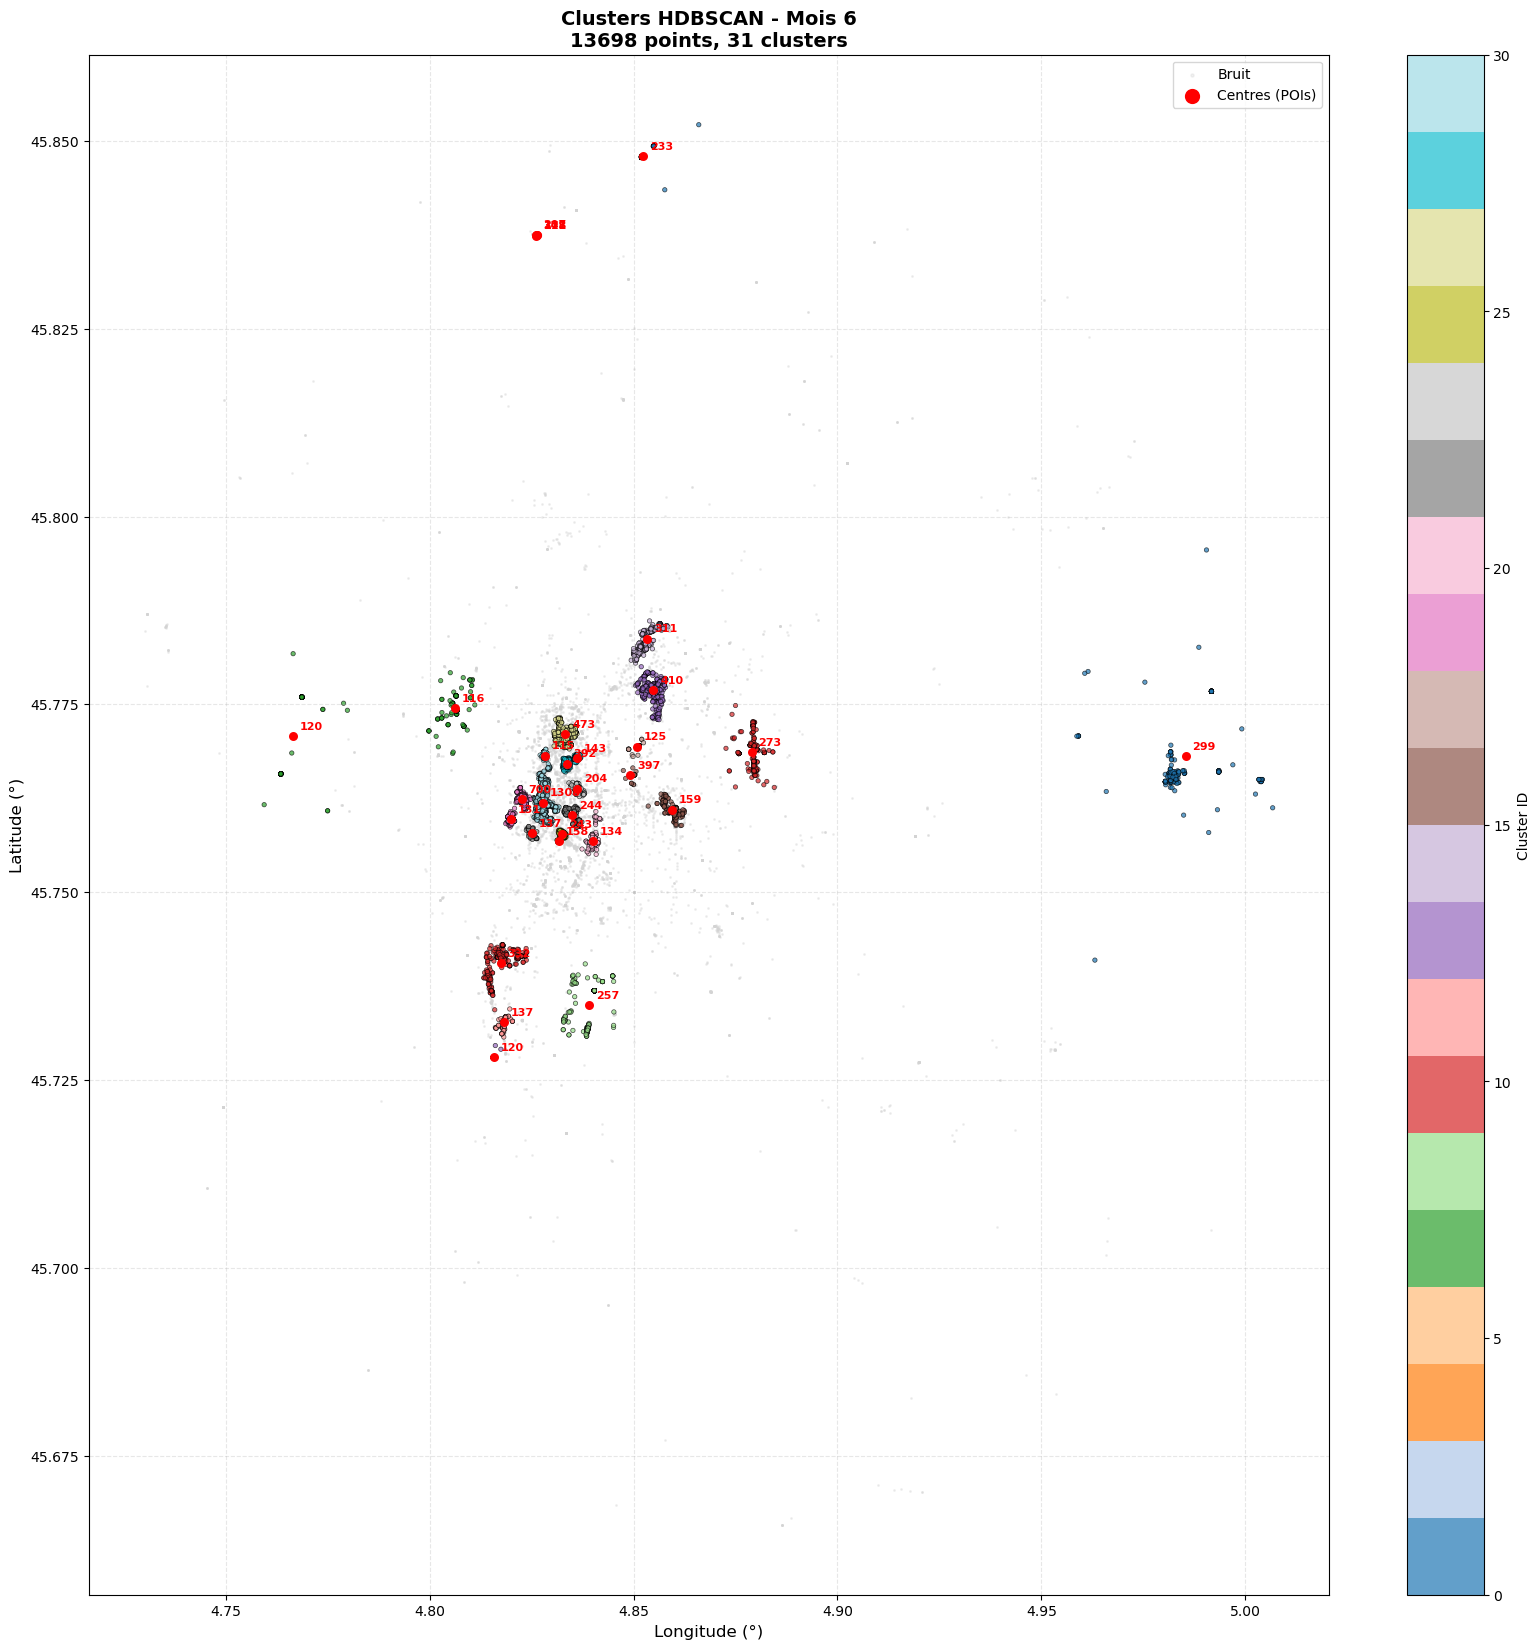

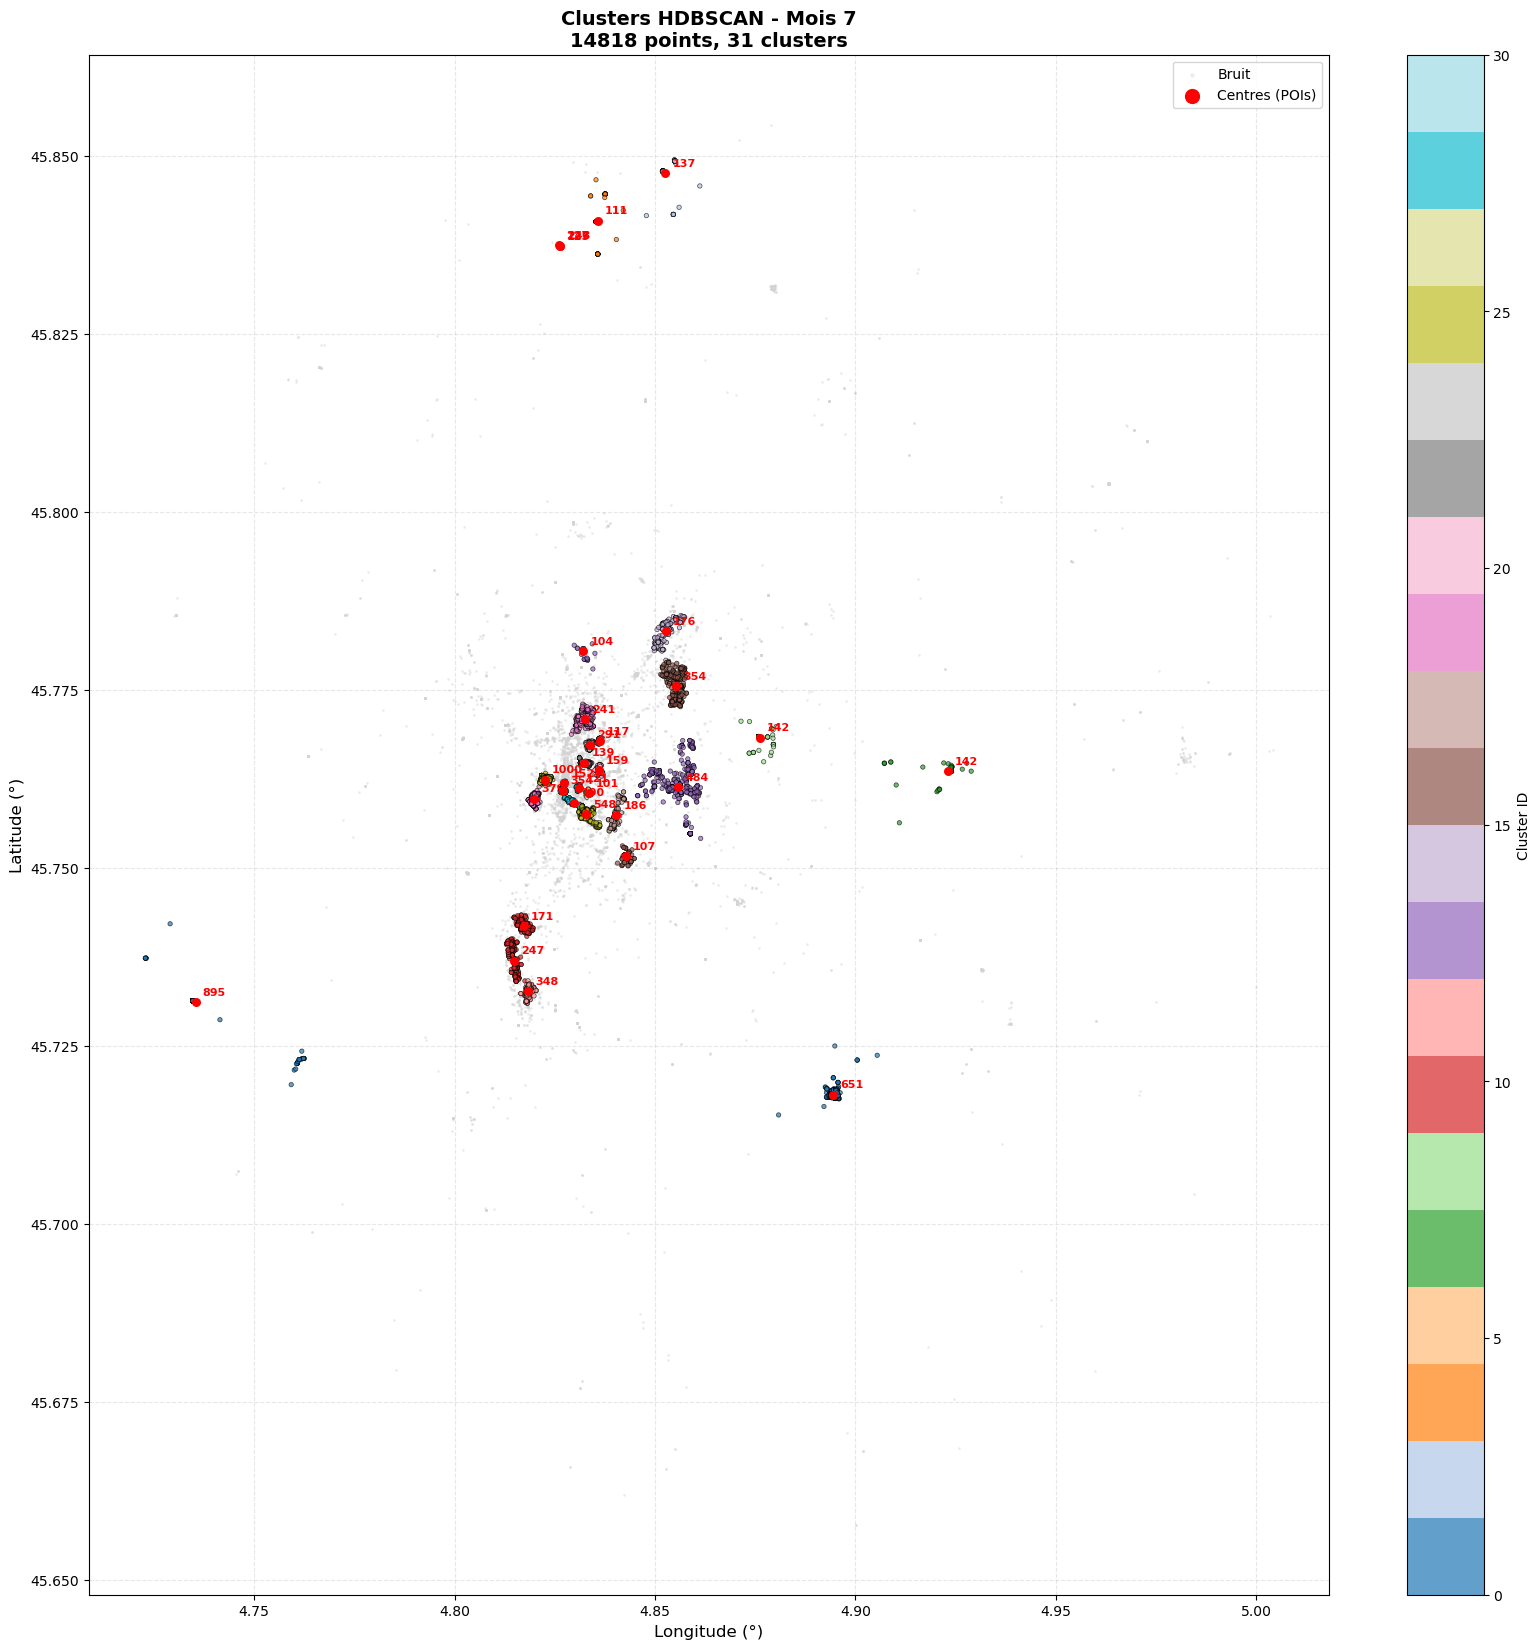

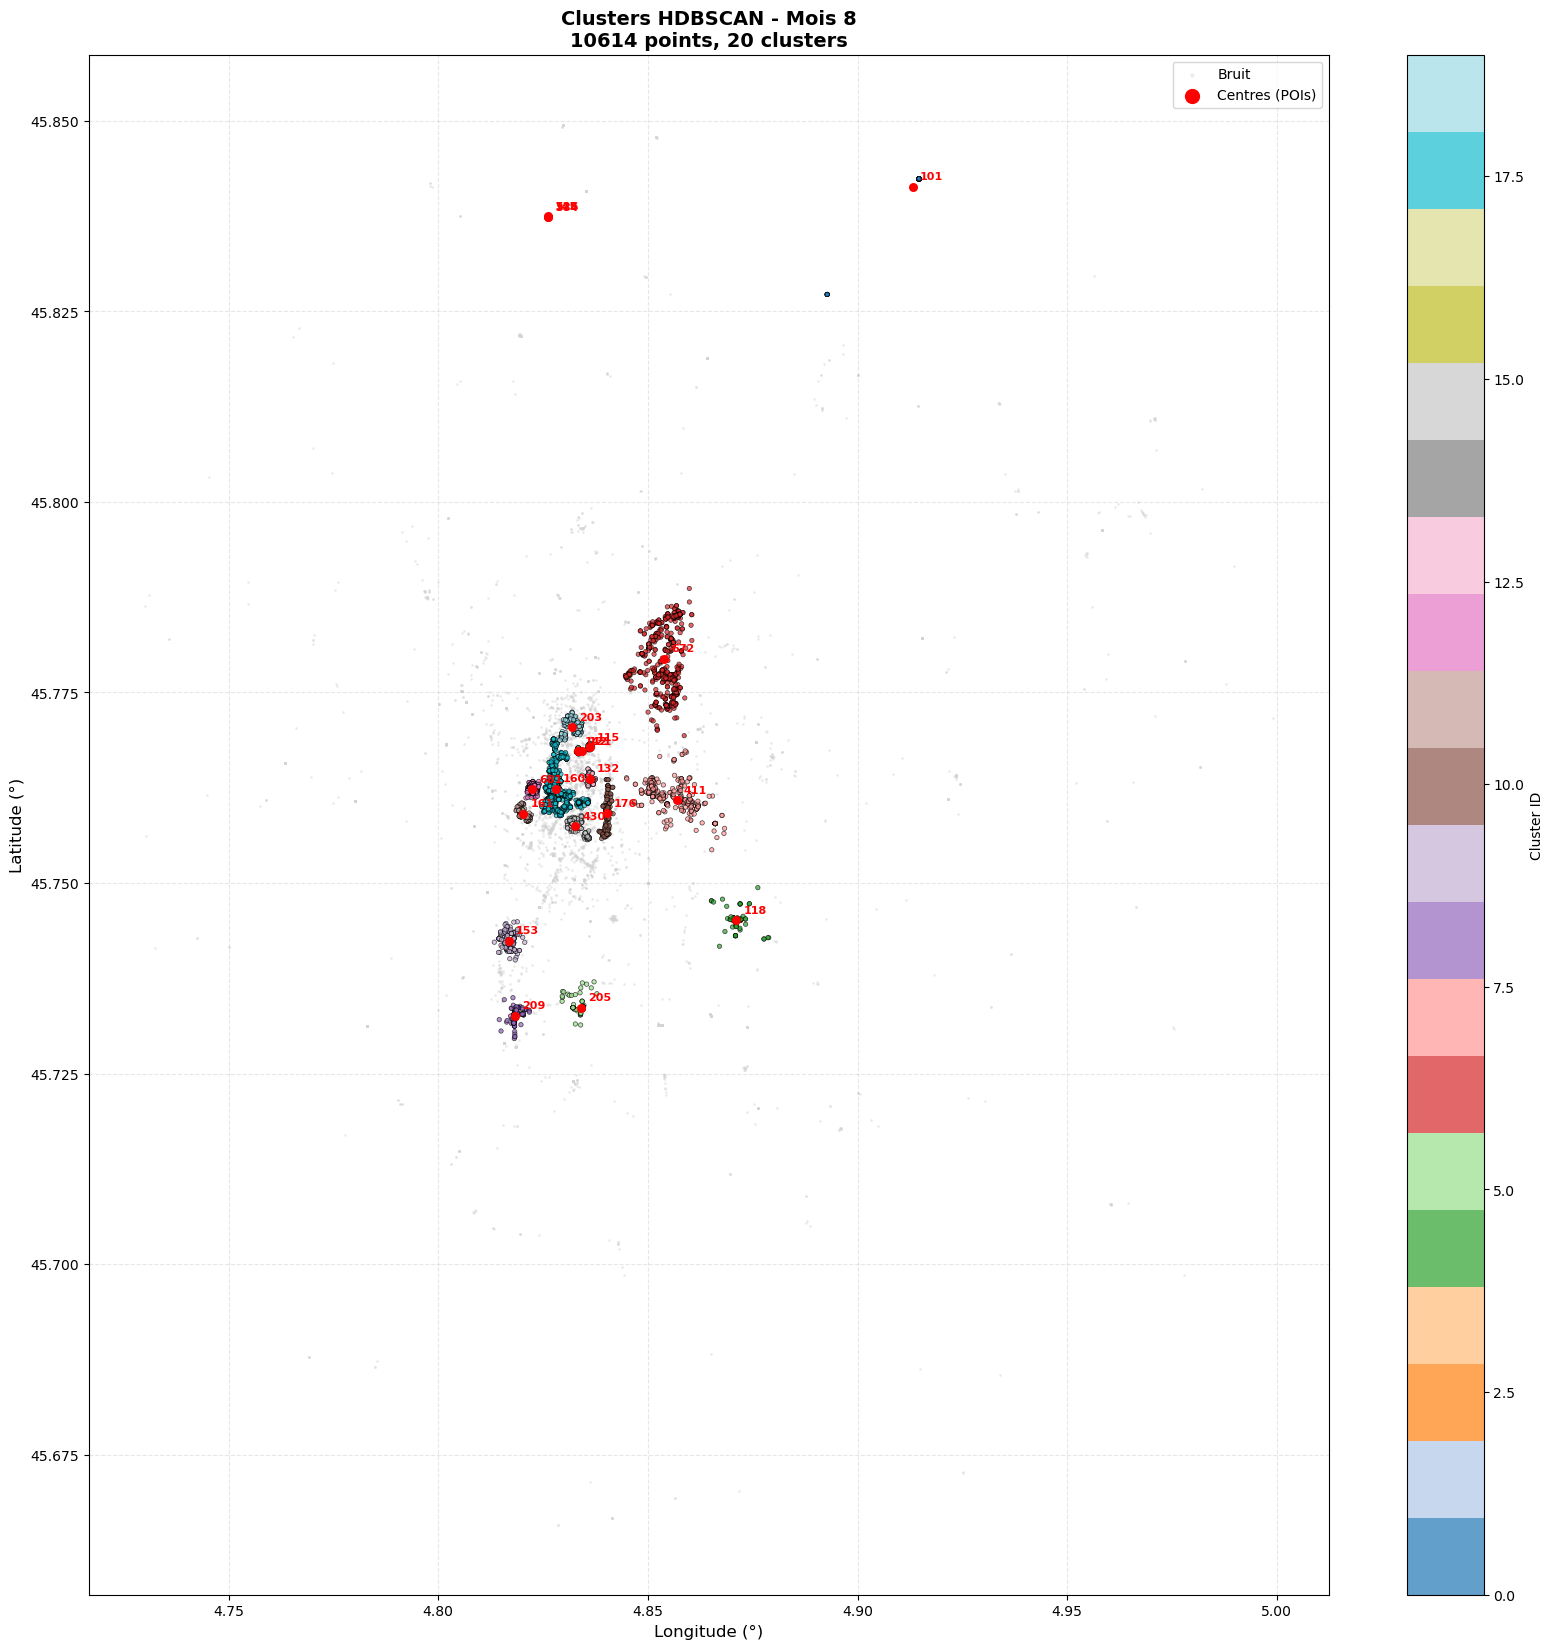

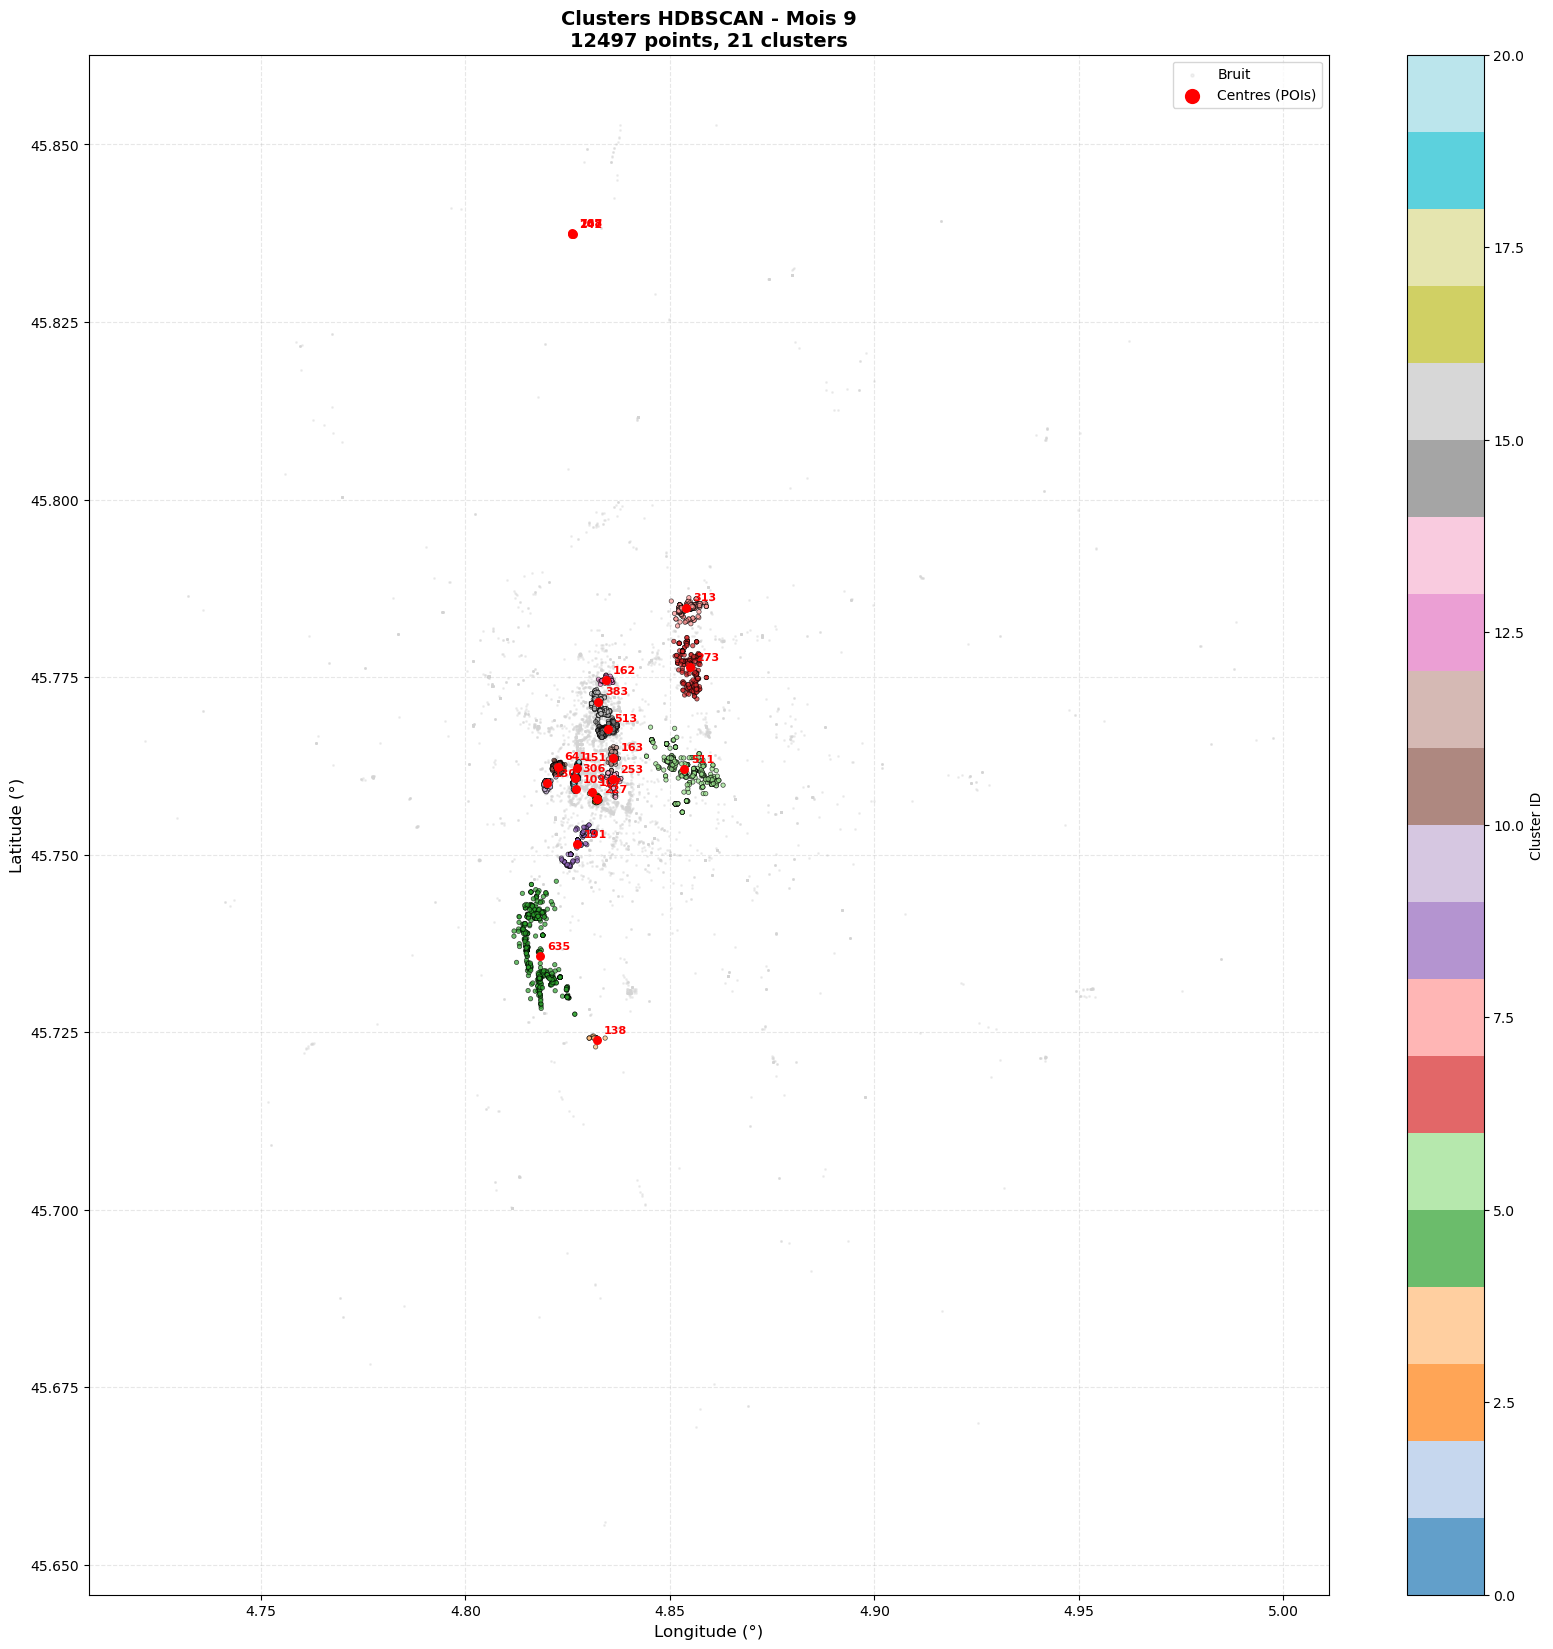

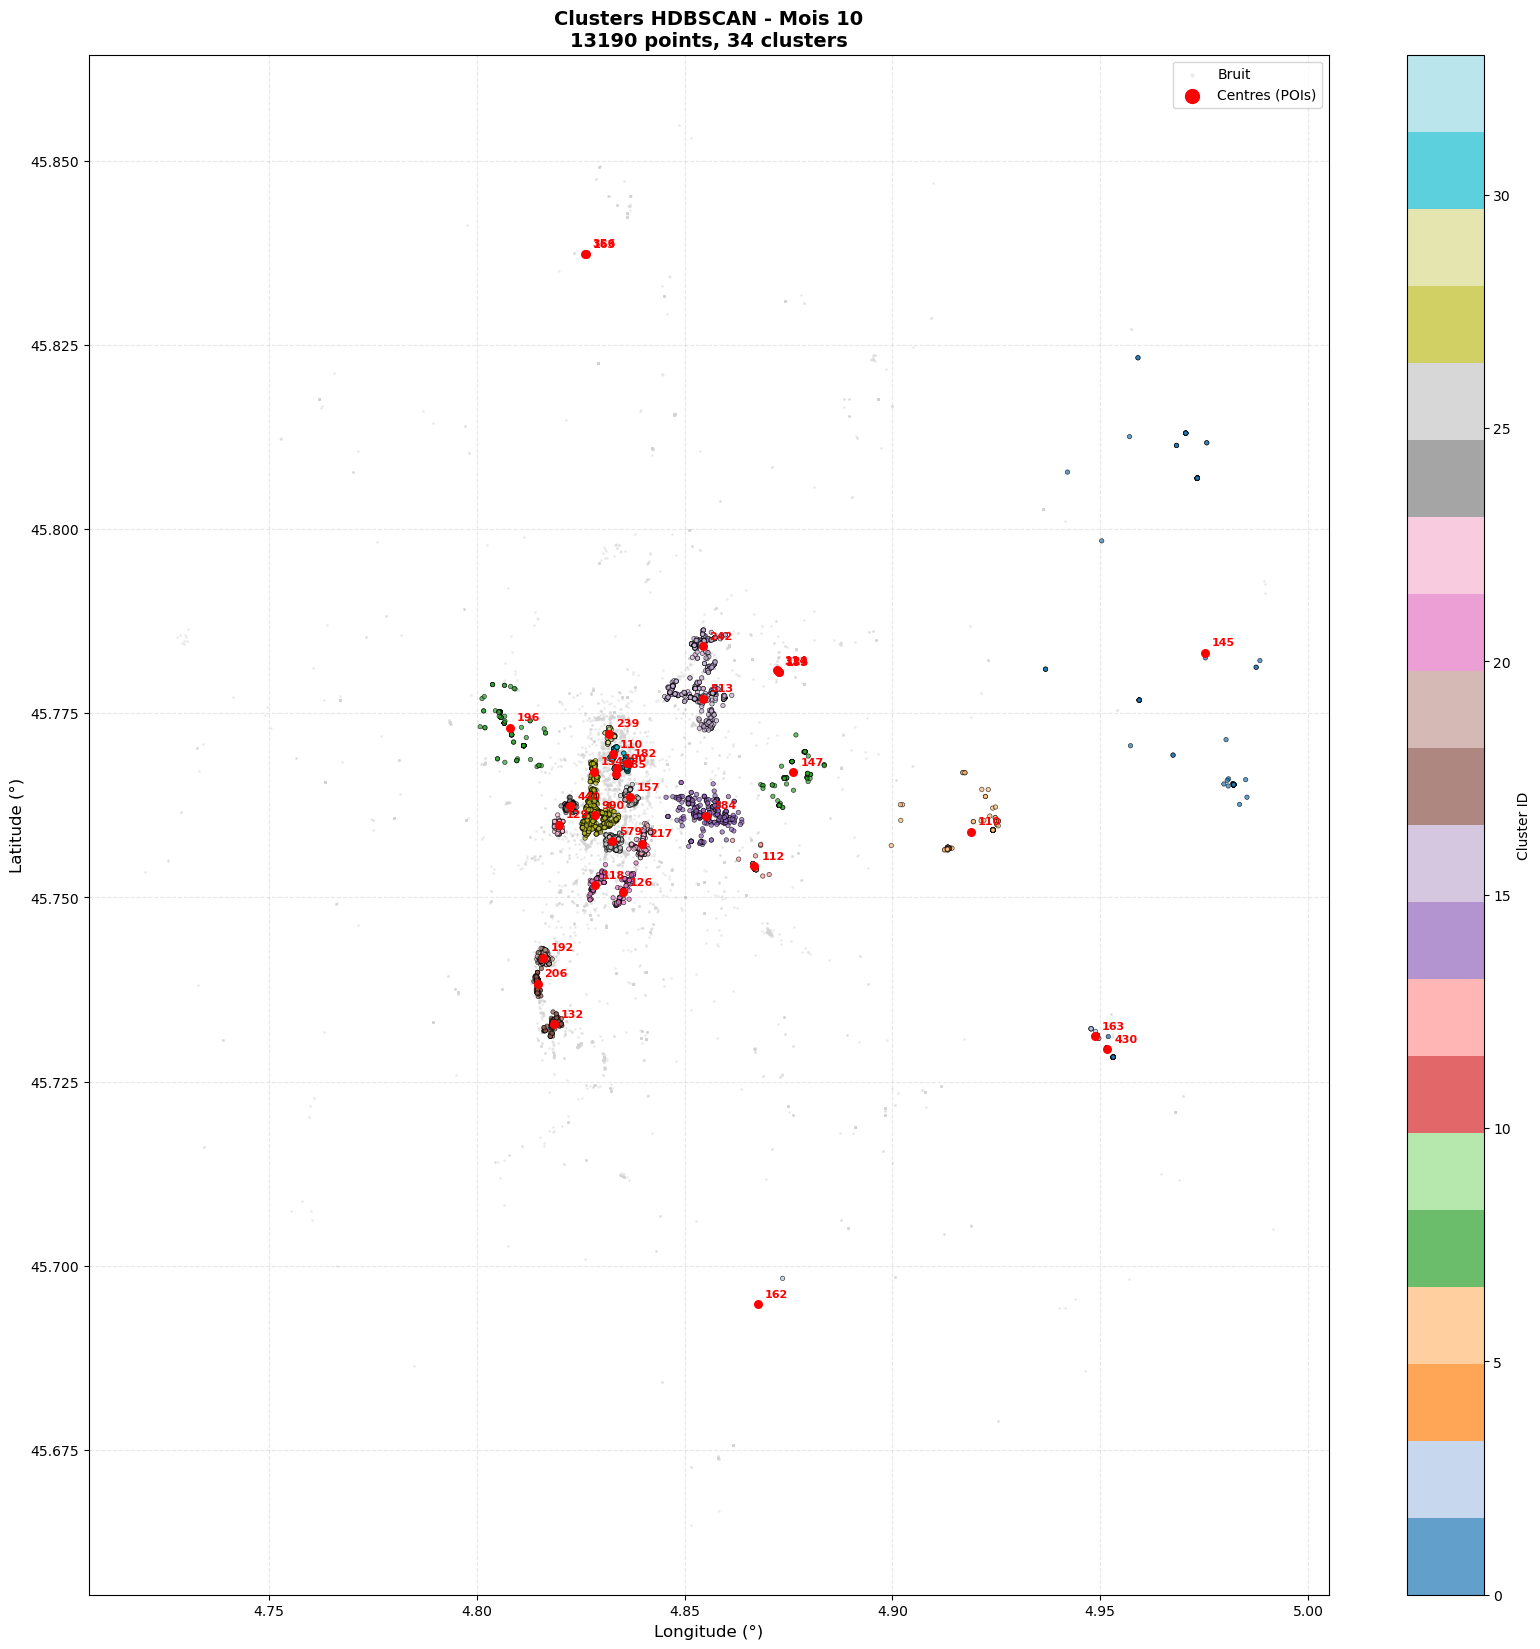

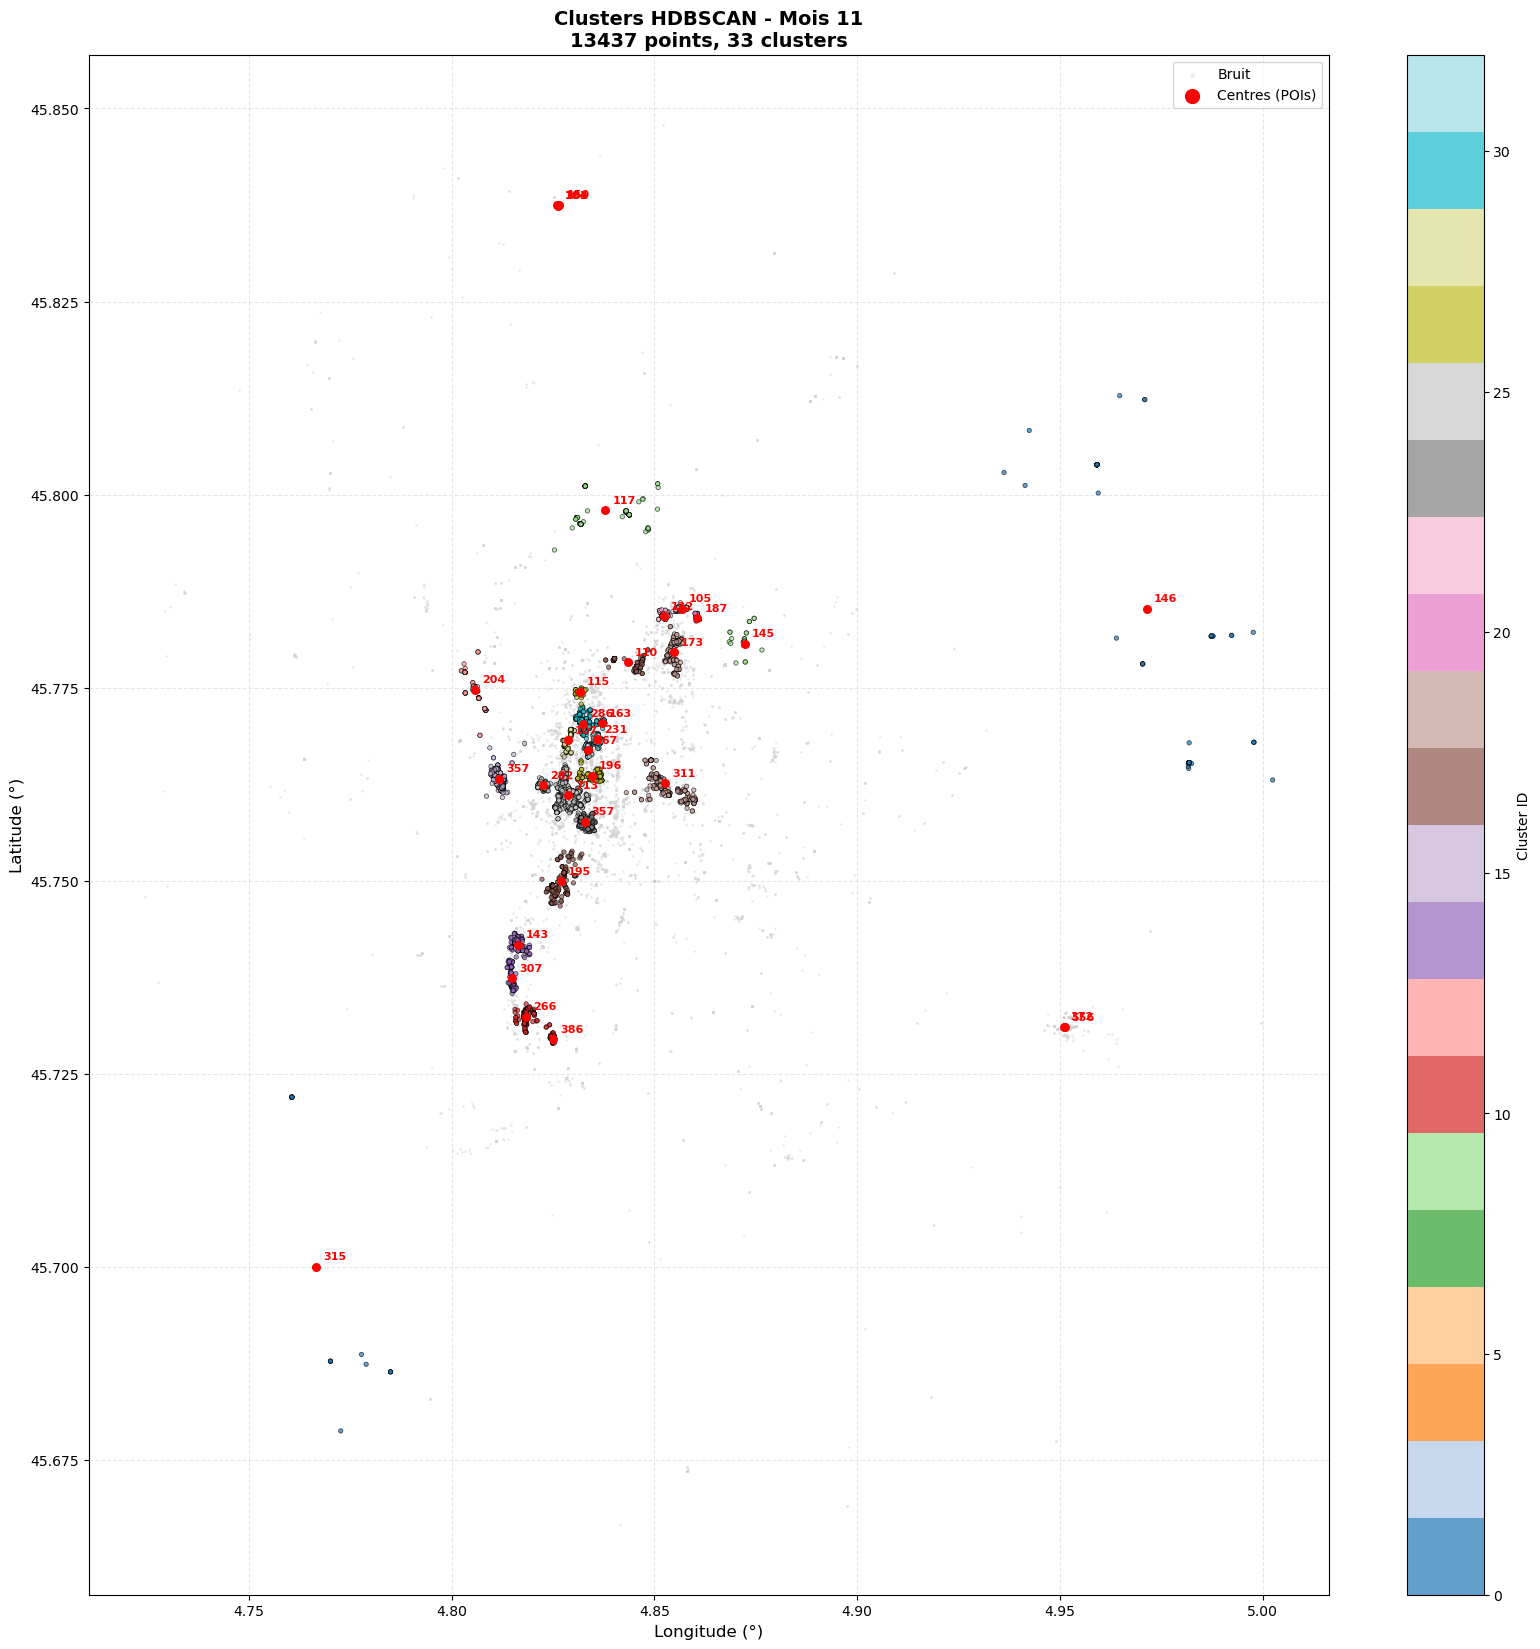

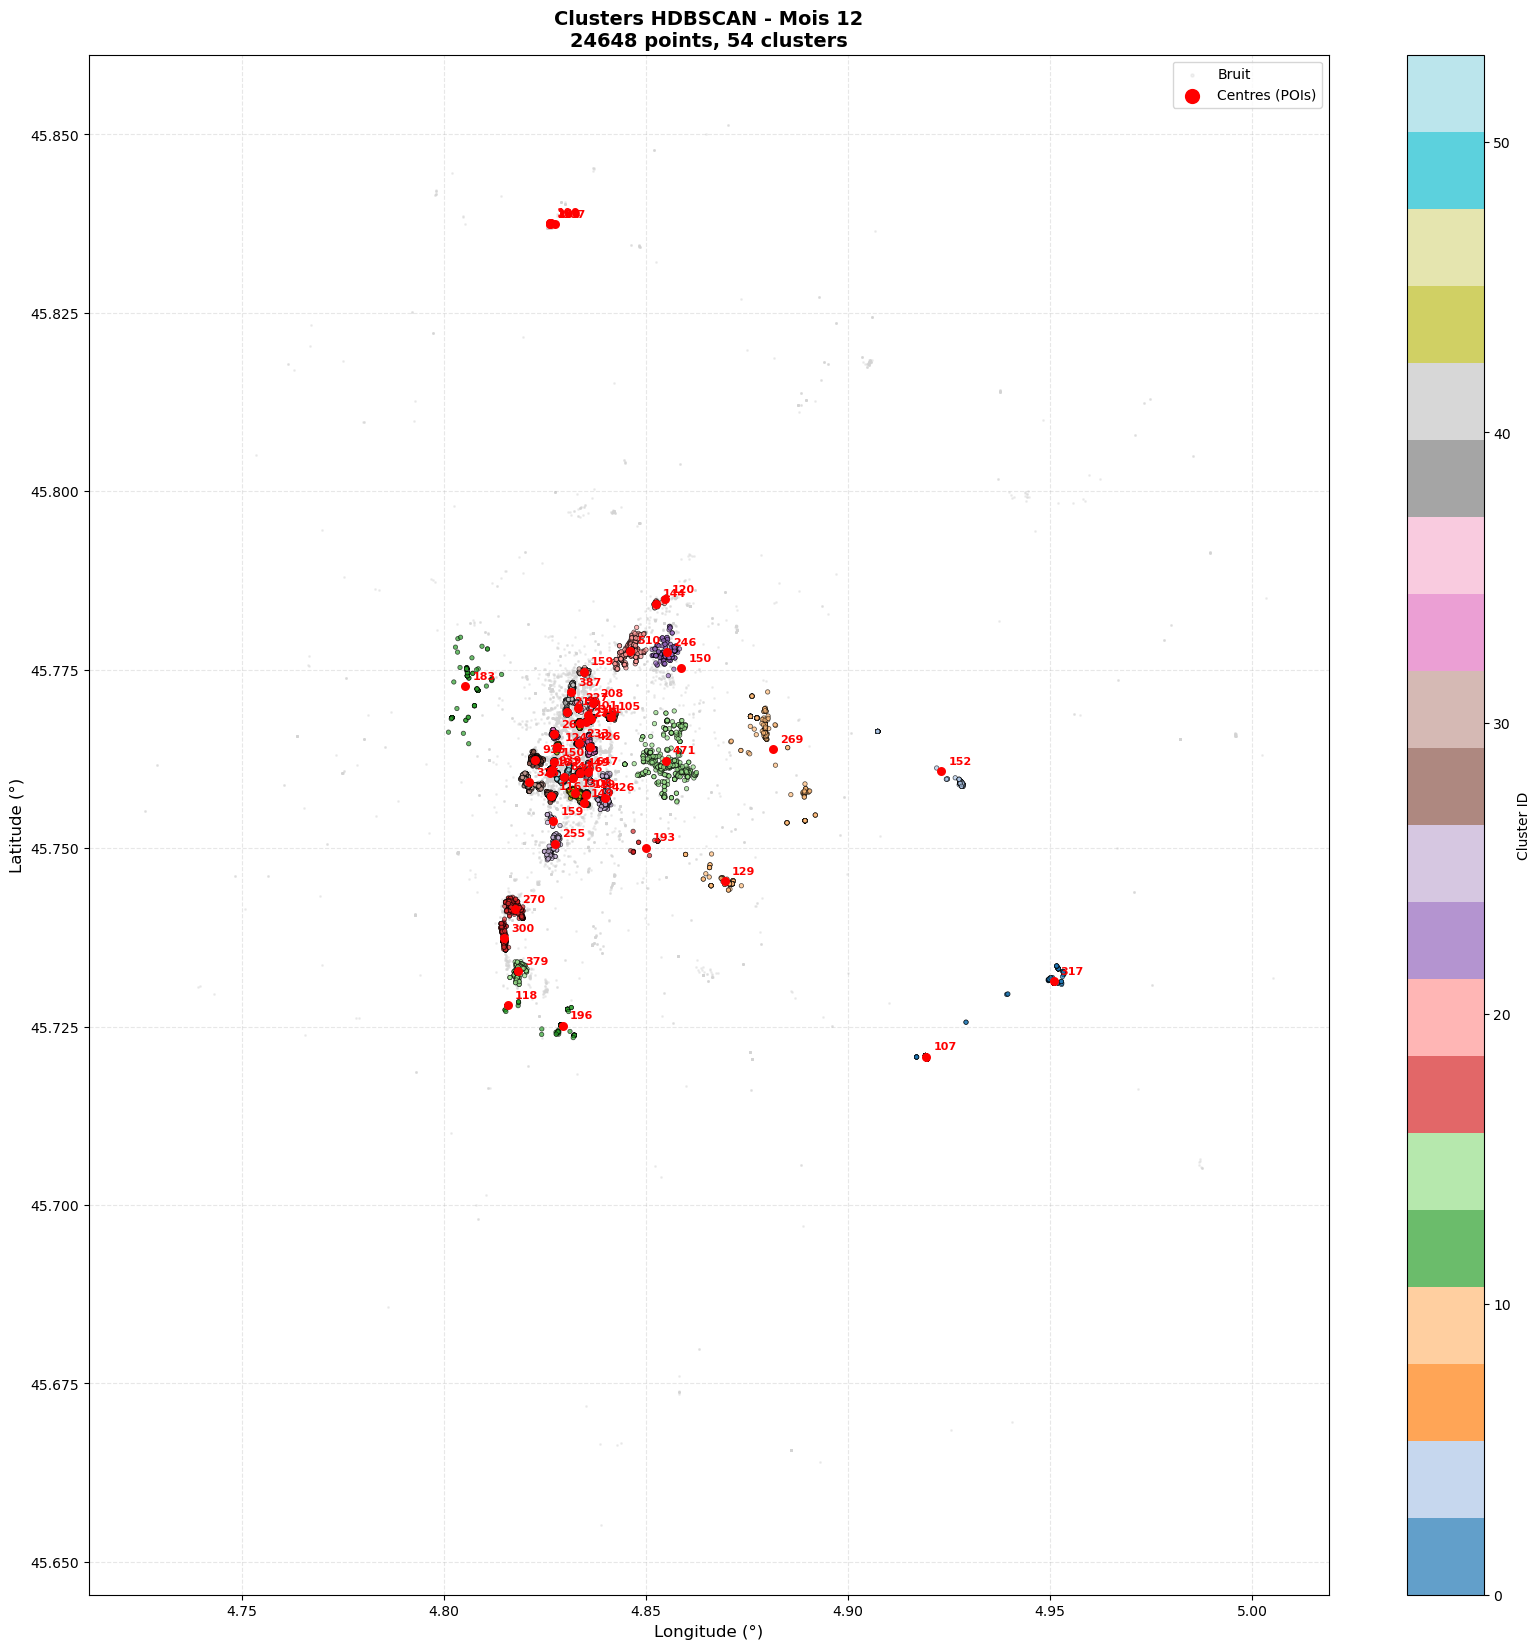

In [22]:
for i in all_df.keys():
    df = all_df[i]
    labels = all_labels[i]
    
    
    plt.figure(figsize=(20, 20))
    
    # Bruit (cluster -1)
    mask_noise = labels == -1
    if np.any(mask_noise):
        plt.scatter(
            df[mask_noise][' long'],
            df[mask_noise][' lat'],
            s=5,
            c='lightgrey',
            alpha=0.3,
            label='Bruit',
            marker='.'
        )
    
    # Clusters
    mask_cluster = labels != -1
    if np.any(mask_cluster):
        scatter = plt.scatter(
            df[mask_cluster][' long'],
            df[mask_cluster][' lat'],
            s=10,
            c=labels[mask_cluster],
            cmap='tab20',
            alpha=0.7,
            edgecolors='black',
            linewidth=0.5
        )
        plt.colorbar(scatter, label='Cluster ID')
    
    # Ajouter les centres des clusters (POIs)
    if i in returned_pois and not returned_pois[i].empty:
        pois = returned_pois[i]
        plt.scatter(
            pois['lon_mean'],
            pois['lat_mean'],
            s=20,
            c='red',
            linewidth=2,
            label='Centres (POIs)',
            zorder=5
        )
        
        # Annoter les centres avec le nombre de photos
        for cluster_id, poi_row in pois.iterrows():
            plt.annotate(
                f"{int(poi_row['nb_photos'])}",
                (poi_row['lon_mean'], poi_row['lat_mean']),
                xytext=(5, 5),
                textcoords='offset points',
                fontsize=8,
                fontweight='bold',
                color='red'
            )
    
    plt.xlabel("Longitude (°)", fontsize=12)
    plt.ylabel("Latitude (°)", fontsize=12)
    plt.title(f"Clusters HDBSCAN - Mois {i}\n{len(df)} points, {len(set(labels)) - (1 if -1 in labels else 0)} clusters", 
              fontsize=14, fontweight='bold')
    plt.legend(markerscale=2, loc='best')
    plt.grid(True, alpha=0.3, linestyle='--')
    plt.show()